# Analyse multidimensionnelle des trajectoires de soins : Jeu de données VICAN

Ce notebook présente l'exploration des hyperparamètres de la méthode SWoTTeD sur un jeu de données de trajectoires oncologiques (1 336 patients, 4 types de traitements, suivi en mois).
L'objectif est d'identifier une configuration produisant à la fois une bonne qualité de reconstruction ($\text{FIT}_X$) et des phénotypes temporels cliniquement interprétables.

## Sommaire

1. Imports et configuration de l'environnement
2. Chargement et préparation des données
3. Initialisation du modèle TCA et construction du tenseur
4. Exploration des hyperparamètres de SWoTTeD
   - 4.1. Variation du rang $R$ et de la taille de fenêtre $\omega$ (sans early stopping, lr=1e-2)
   - 4.2. Réduction du taux d'apprentissage avec early stopping (lr $\in$ {5e-5, 1e-4})
   - 4.3. Ajustement des termes de régularisation : faibles pénalités
   - 4.4. Ajustement des termes de régularisation : fortes pénalités
5. Clustering sur les intensités des phénotypes

## 1. Imports

### 1.1. Librairies

In [54]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import random
import matplotlib.patches as mpatches
import itertools
import time


project_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    src_candidate = base / "src" / "trajectoryclusteringanalysis"
    if src_candidate.exists():
        project_root = base
        break

if project_root is None:
    raise FileNotFoundError(
        f"Could not find project root containing src/trajectoryclusteringanalysis from {Path.cwd()}"
    )

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from trajectoryclusteringanalysis import TCA
from trajectoryclusteringanalysis.plotting import *

print(f"Using local package from: {src_path}")

from trajectoryclusteringanalysis.tca import TCA

Using local package from: c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src


### 1.2. Fonctions

Pour faciliter la suite, on implémente les fonctions suivantes :
- `run_swotted_trial` : fonction d'entraînement
- `plot_training_history` : pour visualiser la courbe d'entraînement (`train_loss` et $\text{FIT}_X$)
- `phenotype_diversity` : pour vérifier qu'on n'a pas de redondance dans les phénotypes

La fonction `phenotype_diversity` est telle que :

Pour chaque paire de phénotypes $(i, j)$, on calcule :
$$d_{\cos}(\mathcal{P}_i, \mathcal{P}_j) = 1 - \frac{\langle \tilde{p}_i, \tilde{p}_j \rangle}{\|\tilde{p}_i\| \cdot \|\tilde{p}_j\|}$$

où $\tilde{p}_r$ est le vecteur aplati et normalisé du phénotype $\mathcal{P}_r$.
La diversité globale est la moyenne sur toutes les paires $(i < j)$ :

$$\text{div}(\mathcal{P}) = \binom{R}{2}^{-1} \sum_{1 \leq i < j \leq R} d_{\cos}(\mathcal{P}_i, \mathcal{P}_j)$$

Une valeur proche de $0$ indique desphénotypes quasi identiques ;
une valeur proche de $1$ indique des phénotypes bien distincts (diversité maximale).

In [55]:
def run_swotted_trial(
    timed_event_structure: pd.DataFrame,
    rank: int,
    time_window_length: int,
    reg_ns: float,
    reg_s: float,
    lr: float,
    n_epochs: int,
    metric: str = 'Bernoulli',
    early_stopping: bool = True,
    early_stopping_patience: int = 10,
    early_stopping_min_delta: float = 1e-4,
    fit_metric_every_n_epochs: int = 10,
    fit_metric_eval_max_patients: int = 64,
    num_workers: int = 0,
) -> dict:
    """Entraîne un modèle SWoTTeD pour une configuration donnée et retourne les résultats.

    Parameters
    ----------
    timed_event_structure : pd.DataFrame
        Données au format long (ID_PATIENT, Time, Event).
    rank : int
        Nombre de phénotypes R.
    time_window_length : int
        Taille de la fenêtre temporelle ω.
    reg_ns : float
        Terme de régularisation de non-succession.
    reg_s : float
        Terme de régularisation de sparsité.
    lr : float
        Taux d'apprentissage.
    n_epochs : int
        Nombre maximum d'epochs.
    metric : str
        Fonction de perte ('Bernoulli' par défaut).
    early_stopping : bool
        Active ou désactive l'early stopping.
    early_stopping_patience : int
        Nombre d'epochs sans amélioration avant arrêt.
    early_stopping_min_delta : float
        Amélioration minimale de FIT_X pour réinitialiser la patience.
    fit_metric_every_n_epochs : int
        Fréquence de calcul de FIT_X approximée.
    fit_metric_eval_max_patients : int
        Nombre de patients utilisés pour l'approximation de FIT_X.
    num_workers : int
        Nombre de workers pour le DataLoader.

    Returns
    -------
    dict
        Dictionnaire contenant les paramètres, les métriques et l'objet tca_trial entraîné.
    """
    print('\n' + '=' * 90)
    print(f"rank={rank}, twl={time_window_length}, reg_ns={reg_ns}, "
          f"reg_s={reg_s}, learning_rate={lr}")

    tca_trial = TCA(
        data=timed_event_structure,
        index_col='ID_PATIENT',
        time_col='Time',
        event_col='Event',
        mode='multidimensional',
    )
    tca_trial.analyzer.transform_time_event_structure_to_tensor()
    tensor_trial = tca_trial.analyzer.get_tensor()

    t0 = time.perf_counter()
    tca_trial.analyzer.fit_swotted_decomposition(
        tensor_trial,
        rank,
        time_window_length,
        reg_ns,
        reg_s,
        metric,
        lr,
        n_epochs,
        fit_metric_every_n_epochs=fit_metric_every_n_epochs,
        fit_metric_eval_max_patients=fit_metric_eval_max_patients,
        restore_best_fit_checkpoint=early_stopping,
        num_workers=num_workers,
        early_stopping_patience=early_stopping_patience if early_stopping else None,
        early_stopping_min_delta=early_stopping_min_delta,
        early_stopping_monitor='fit_metric',
    )
    elapsed = time.perf_counter() - t0

    hist = getattr(tca_trial.analyzer, 'training_history', {}) or {}
    best_fit       = hist.get('best_fit_metric', None)
    best_fit_epoch = hist.get('best_fit_metric_epoch', None)
    final_fit      = hist.get('final_fit_metric', None)
    epochs_run     = len(hist.get('epoch', []))

    print(f"  best_fit_metric={best_fit:.4f}, final_fit_metric={final_fit:.4f}, "
          f"epochs={epochs_run}, temps={elapsed:.1f}s")

    return {
        'rank':              rank,
        'time_window_length': time_window_length,
        'reg_term_ns':       reg_ns,
        'reg_term_s':        reg_s,
        'learning_rate':     lr,
        'epochs_run':        epochs_run,
        'best_fit_metric':   best_fit,
        'best_fit_epoch':    best_fit_epoch,
        'final_fit_metric':  final_fit,
        'elapsed_s':         round(elapsed, 2),
        'tca_trial':         tca_trial,
    }


def build_results_df(results: list) -> pd.DataFrame:
    """Convertit une liste de résultats en DataFrame trié par meilleur FIT_X décroissant."""
    df = pd.DataFrame(results)
    if not df.empty:
        df = df.sort_values(
            by=['best_fit_metric', 'final_fit_metric'],
            ascending=False,
            na_position='last'
        ).reset_index(drop=True)
    return df

In [56]:
def plot_training_history(row, title_suffix=""):
    """Affiche la courbe d'entraînement (train_loss + FIT_X approx.) pour une configuration.
    
    Parameters
    ----------
    row : dict ou pd.Series
        Ligne du DataFrame de résultats contenant 'tca_trial' et les métadonnées.
    title_suffix : str
        Suffixe optionnel ajouté au titre du graphique.
    """
    tca_trial = row['tca_trial']
    history = getattr(tca_trial.analyzer, 'training_history', None)

    if not history or len(history.get('epoch', [])) == 0:
        raise ValueError("Aucun historique d'entraînement disponible.")

    epochs          = history['epoch']
    train_loss      = history['train_loss_total']
    fit_epochs      = history['fit_metric_points_epoch']
    fit_values      = history['fit_metric_points_value']

    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.plot(epochs, train_loss, color='tab:blue', linewidth=2, label='train_loss_total')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('train_loss_total', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(alpha=0.25)

    ax2 = ax1.twinx()
    if fit_epochs:
        ax2.plot(fit_epochs, fit_values, color='tab:green',
                 marker='o', linestyle='--', label='FIT metric')
        for i, (x, y) in enumerate(zip(fit_epochs, fit_values)):
            if i % 2 == 0:
                y_offset = 10 if i % 4 == 0 else -15
                ax2.annotate(f"{y:.4f}", (x, y),
                             textcoords='offset points',
                             xytext=(0, y_offset),
                             ha='center', fontsize=9)
        fit_min, fit_max = min(fit_values), max(fit_values)
        fit_span = max(fit_max - fit_min, 1e-6)
        ax2.set_ylim(fit_min - 0.05 * fit_span, fit_max + 0.20 * fit_span)

    ax2.set_ylabel('FIT metric (approx.)', color='tab:green')
    ax2.tick_params(axis='y', labelcolor='tab:green')

    lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
    labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
    ax1.legend(lines, labels, loc='best')

    cfg = (f"R={row['rank']}, ω={row['time_window_length']}, "
           f"α={row['reg_term_s']}, γ={row['reg_term_ns']}, "
           f"lr={row['learning_rate']}")
    plt.title(f"Training — {cfg}{(' — ' + title_suffix) if title_suffix else ''}")
    plt.tight_layout()
    plt.show()

In [57]:
def phenotype_diversity(Ph_tensor: torch.Tensor, eps: float = 1e-12):
    """Calcule la diversité cosinus moyenne entre les R phénotypes.

    Parameters
    ----------
    Ph_tensor : torch.Tensor
        Tenseur de forme (R, N, w).
    eps : float
        Valeur pour la stabilité numérique lors de la normalisation.

    Returns
    -------
    div_value : float
        Diversité moyenne 1 - cosinus, dans [0, 1].
    pairwise_div : torch.Tensor
        Matrice de diversité par paires de forme (R, R), diagonale à 0.
    """
    if not isinstance(Ph_tensor, torch.Tensor):
        Ph_tensor = torch.as_tensor(Ph_tensor, dtype=torch.float32)

    if Ph_tensor.ndim != 3:
        raise ValueError(f"Forme attendue (R, N, w), reçu {tuple(Ph_tensor.shape)}")

    R = Ph_tensor.shape[0]
    if R < 2:
        return 0.0, torch.zeros((R, R), dtype=Ph_tensor.dtype, device=Ph_tensor.device)

    # Aplatissement (N, w) → vecteur R^(N*w) puis normalisation L2
    P = Ph_tensor.reshape(R, -1).float()
    P = F.normalize(P, p=2, dim=1, eps=eps)

    # Matrice de similarité cosinus
    cos_sim = P @ P.T

    # Matrice de diversité : 1 - cos(P_i, P_j)
    pairwise_div = 1.0 - cos_sim
    pairwise_div.fill_diagonal_(0.0)

    # Moyenne sur les paires (i < j)
    upper_idx = torch.triu_indices(R, R, offset=1, device=pairwise_div.device)
    div_value = pairwise_div[upper_idx[0], upper_idx[1]].mean().item()

    return div_value, pairwise_div


def print_diversity(row):
    """Affiche la diversité phénotypique et la matrice par paires pour une configuration."""
    tca_trial = row['tca_trial']
    Ph_tensor = tca_trial.analyzer.model.Ph.detach()
    div_value, pairwise_div = phenotype_diversity(Ph_tensor)

    print(f"Diversité phénotypique (moyenne 1 - cosinus) : {div_value:.6f}\n")

    R = pairwise_div.shape[0]
    col_names = [f"Phénotype_{i+1}" for i in range(R)]
    df = pd.DataFrame(
        pairwise_div.cpu().numpy(),
        index=col_names,
        columns=col_names,
    )
    display(df)

## 2. Chargement et préparation des données

### 2.1. Chargement

Le jeu de données est au format long : chaque ligne correspond à l'occurrence d'un événementpour un patient à un instant donné. 
Les quatre types d'événements sont : chirurgie, chimiothérapie IV, chimiothérapie per os et radiothérapie.

In [58]:
df = pd.read_csv(project_root / "data" / "multidimensional_data.csv")
print(f"Dimensions : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"Colonnes   : {list(df.columns)}")
df.head()

Dimensions : 20435 lignes, 3 colonnes
Colonnes   : ['PATIENT_ID', 'EVENT', 'TIME']


,PATIENT_ID,EVENT,TIME
0,1,Chirurgie,0
1,1,Chimiothérapie IV,1
2,1,Chimiothérapie IV,1
3,1,Chimiothérapie IV,2
4,1,Chimiothérapie IV,3


### 2.2. Encodage des événements

Les labels des événements sont encodés en entiers pour être passés au modèle TCA. On conserve `noms_events` pour les visualisations.

In [59]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
timed_event_structure = df.copy()
timed_event_structure['Event'] = label_encoder.fit_transform(timed_event_structure['EVENT'])
timed_event_structure.drop(columns=['EVENT'], inplace=True)
timed_event_structure.columns = ['ID_PATIENT', 'Time', 'Event']

noms_events = label_encoder.classes_
print(f"Événements encodés : {list(noms_events)}")
timed_event_structure.head()

Événements encodés : ['Chimiothérapie IV', 'Chimiothérapie per os', 'Chirurgie', 'Radiothérapie']


,ID_PATIENT,Time,Event
0,1,0,2
1,1,1,0
2,1,1,0
3,1,2,0
4,1,3,0


### 2.3. Statistiques descriptives

In [60]:
n_patients = timed_event_structure['ID_PATIENT'].nunique()
n_events   = timed_event_structure['Event'].nunique()
duree_max  = timed_event_structure['Time'].max()
duree_moy  = timed_event_structure.groupby('ID_PATIENT')['Time'].max().mean()

print(f"Nombre de patients         : {n_patients}")
print(f"Nombre de types d'événements : {n_events}")
print(f"Durée maximale de suivi    : {duree_max} mois")
print(f"Durée moyenne de suivi     : {duree_moy:.1f} mois")

Nombre de patients         : 1336
Nombre de types d'événements : 4
Durée maximale de suivi    : 23 mois
Durée moyenne de suivi     : 7.6 mois


In [61]:
# Patients ayant reçu les 4 types de traitements au moins une fois
all_events = set(timed_event_structure['Event'].unique())
patients_complets = (
    timed_event_structure
    .groupby('ID_PATIENT')
    .filter(lambda g: set(g['Event']) == all_events)
    ['ID_PATIENT'].unique()
)
print(f"Nombre de patients ayant reçu les {len(all_events)} traitements : {len(patients_complets)}")

Nombre de patients ayant reçu les 4 traitements : 50


## 3. Initialisation du modèle TCA et du tenseur

### 3.1. Initialisation du modèle TCA

On instancie le modèle TCA en mode multidimensionnel en lui passant le jeu de données.

In [62]:
tca = TCA(
    data=timed_event_structure,
    index_col='ID_PATIENT',
    alphabet=noms_events,
    states=noms_events,
    time_col='Time',
    event_col='Event',
    mode='multidimensional',
)

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.


Dataset :
data shape:  (20435, 3)
state coding:
                 alphabet                  label  label encoded
0      Chimiothérapie IV      Chimiothérapie IV              1
1  Chimiothérapie per os  Chimiothérapie per os              2
2              Chirurgie              Chirurgie              3
3          Radiothérapie          Radiothérapie              4


### 3.2. Construction du tenseur

Les données sont converties en tenseur  de dimension $K \times n \times T_k$ (patients × événements × temps).

In [63]:
tca.analyzer.transform_time_event_structure_to_tensor()
tensor = tca.analyzer.get_tensor()

shape = tca.analyzer.get_tensor_shape()
print(f"Nombre de patients  : {shape[0]}")
print(f"Nombre d'événements : {shape[1]}")
print(f"Durée maximale      : {shape[2]} mois")

Nombre de patients  : 1336
Nombre d'événements : 4
Durée maximale      : 24 mois


### 3.3. Visualisation d'une trajectoire individuelle

On visualise la matrice d'un patient ayant reçu les 4 types de traitements, afin de vérifier que le tenseur a bien été construit.

Patient utilise pour la visualisation: 8


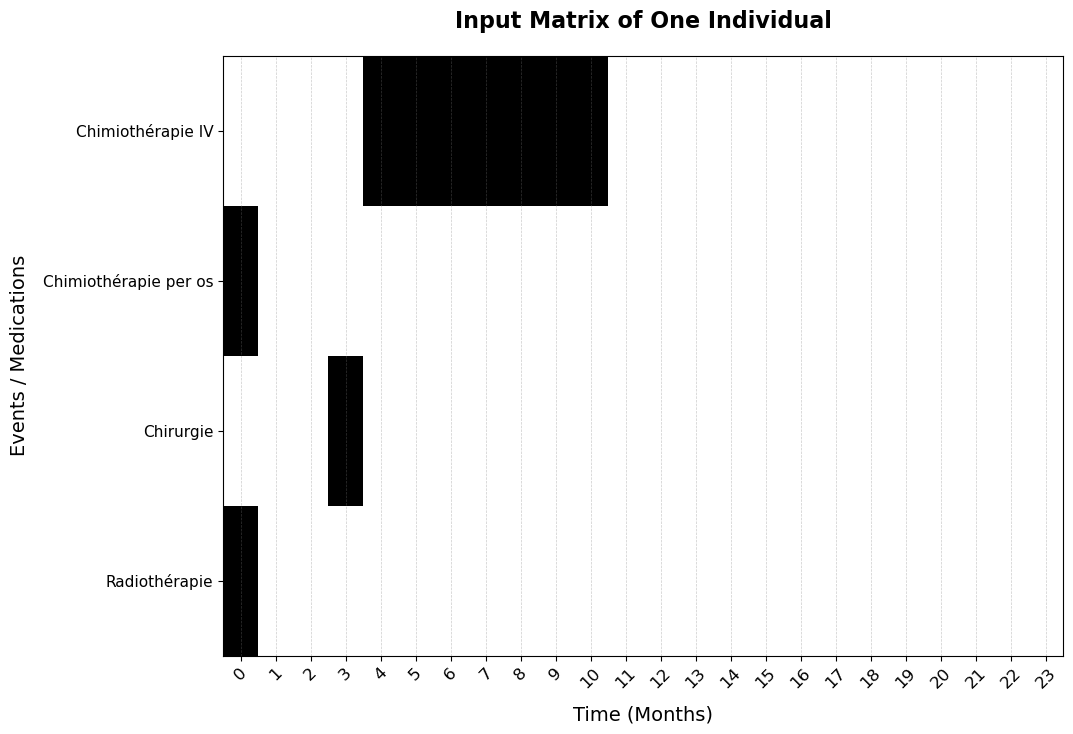

     PATIENT_ID                  EVENT  TIME
561          23              Chirurgie     0
562          23  Chimiothérapie per os     0
563          23          Radiothérapie     0
564          23          Radiothérapie     0
565          23          Radiothérapie     0
566          23          Radiothérapie     0
567          23      Chimiothérapie IV     4
568          23      Chimiothérapie IV     5
569          23      Chimiothérapie IV     5
570          23      Chimiothérapie IV     6
571          23      Chimiothérapie IV     7
572          23      Chimiothérapie IV     7
573          23      Chimiothérapie IV     8
574          23      Chimiothérapie IV     8
575          23      Chimiothérapie IV     9
576          23      Chimiothérapie IV    10
577          23      Chimiothérapie IV    13
578          23      Chimiothérapie IV    13
579          23      Chimiothérapie IV    14
580          23      Chimiothérapie IV    15
581          23      Chimiothérapie IV    17
582       

In [8]:
patient_index = int(patients_with_all_events[0])
print(f"Patient utilise pour la visualisation: {patient_index}")

plot_input_matrix(tensor, id=patient_index, labels=tca.label_to_encoded, time_unit='Months')

print(df[df['PATIENT_ID'] == 23])

## 4. Exploration des hyperparamètres de SWoTTeD

L'objectif de cette section est d'identifier une configuration d'hyperparamètres permettant d'obtenir simultanément une bonne qualité de reconstruction $\text{FIT}_X$ et des phénotypes temporels cliniquement interprétables.

La démarche est la suivante :
- on commence par explorer le rang $R$ et la taille de fenêtre $\omega$ sans early stopping ;
- on introduit ensuite l'early stopping et on réduit le taux d'apprentissage ;
- on fait enfin varier les termes de régularisation $\alpha$ et $\gamma$.

Pour chaque configuration, deux critères sont suivis :
- $\mathbf{FIT_X}$ : qualité globale de reconstruction des trajectoires ;
- **Diversité phénotypique** : degré de différenciation entre les phénotypes appris.

### 4.1. Variation du rang R et de la taille de fenêtre ω

On fait varier $R \in \{2, 3, 4, 5\}$ et $\omega \in \{2, 3, 4\}$, soit 12 configurations. Les autres hyperparamètres sont fixés : $\alpha = \gamma = 0{,}5$, lr $= 10^{-2}$,
200 epochs, sans early stopping.

Le critère de comparaison retenu est le meilleur $\text{FIT}_X$ approximé atteint au cours de l'entraînement, et non sa valeur à la dernière epoch, en raison de l'instabilité observée en fin d'entraînement.

In [64]:
n_epochs = 200
ranks    = [2, 3, 4, 5]
windows  = [2, 3, 4]
s        = 0.5
ns       = 0.5
lr       = 1e-2
results1 = []

for r in ranks:
    for w in windows:
        results1.append(run_swotted_trial(
            timed_event_structure, r, w,
            reg_ns=ns, reg_s=s, lr=lr, n_epochs=n_epochs,
            early_stopping=False,
        ))

results_df1 = build_results_df(results1)
display(results_df1.drop(columns='tca_trial'))

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.



rank=2, twl=2, reg_ns=0.5, reg_s=0.5, learning_rate=0.01
Dataset :
data shape:  (20435, 3)
state coding:
    label  label encoded
0      0              0
1      1              1
2      2              2
3      3              3


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.



 -> Starting training



  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model        | SlidingWindow | 0      | train | 0    
  | other params | n/a           | 16     | n/a   | n/a  
---------------------------------------------------------------
16        Trainable params
0         Non-trainable params
16        Total params
0.000     Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
0         Total Flops
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


...

Training: |          | 0/? [00:00<?, ?it/s]

Epoch 1/200 : - train_loss_Ph: 14.914615 - train_loss_W: 24.775616 - train_loss_total: 39.690230 - duration: 5.17s - FIT metric: 0.1702
    checkpoint: New best FIT metric = 0.1702 at epoch 1.
Epoch 2/200 : - train_loss_Ph: 14.880760 - train_loss_W: 24.412830 - train_loss_total: 39.293591 - duration: 5.06s
Epoch 3/200 : - train_loss_Ph: 14.623877 - train_loss_W: 23.817833 - train_loss_total: 38.441710 - duration: 5.36s
Epoch 4/200 : - train_loss_Ph: 14.380055 - train_loss_W: 23.215717 - train_loss_total: 37.595773 - duration: 5.81s
Epoch 5/200 : - train_loss_Ph: 14.478676 - train_loss_W: 23.017544 - train_loss_total: 37.496220 - duration: 5.66s
Epoch 6/200 : - train_loss_Ph: 14.214031 - train_loss_W: 22.421118 - train_loss_total: 36.635149 - duration: 4.95s
Epoch 7/200 : - train_loss_Ph: 14.099471 - train_loss_W: 22.006582 - train_loss_total: 36.106053 - duration: 6.17s
Epoch 8/200 : - train_loss_Ph: 14.078269 - train_loss_W: 21.674250 - train_loss_total: 35.752519 - duration: 5.09s
Ep


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\IPython\core\interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


La configuration $R=4$, $\omega=2$ obtient le meilleur $\text{FIT}_X$ max approximé, aux alentours de $0{,}5$, mais on peut voir qu'à la fin de l'entraînement, $\text{FIT}_X$ devient très négative.
On visualise ses phénotypes, sa courbe d'entraînement et la reconstruction d'un patient.


Configuration #1 : rank=4, twl=2, reg_ns=0.5, reg_s=0.5, learning rate=0.01
  best_fit_metric=0.5399, final_fit_metric=-3.7408
Decomposed into 1336 pathways with rank 4 and time window length 2
Success rate for the entire dataset: -3.7474


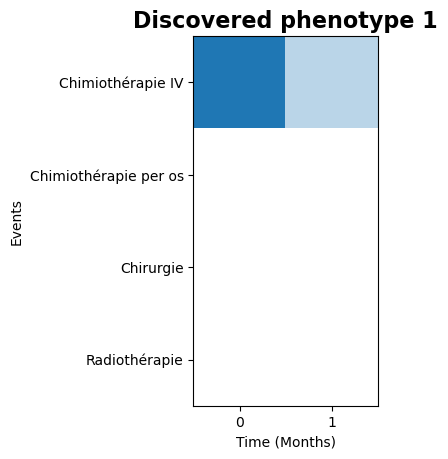

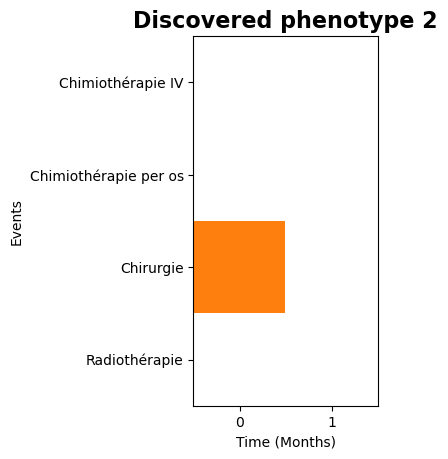

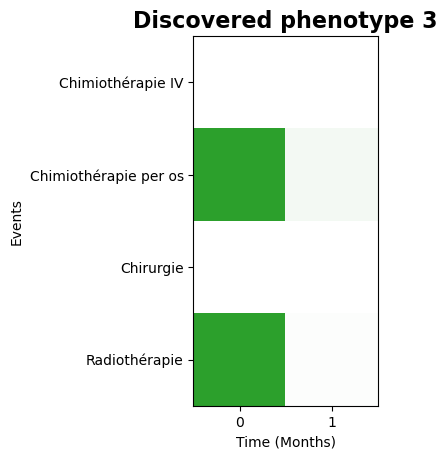

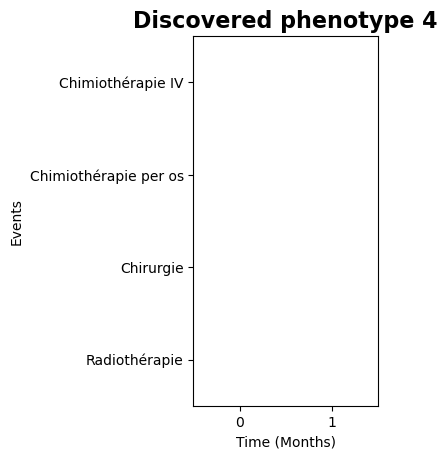

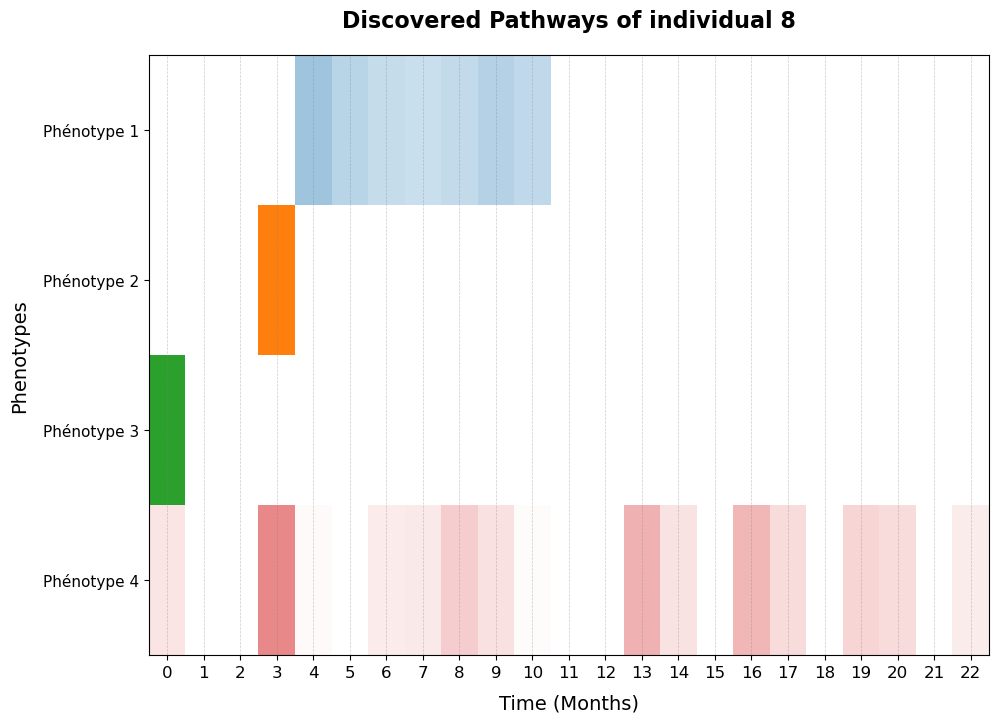

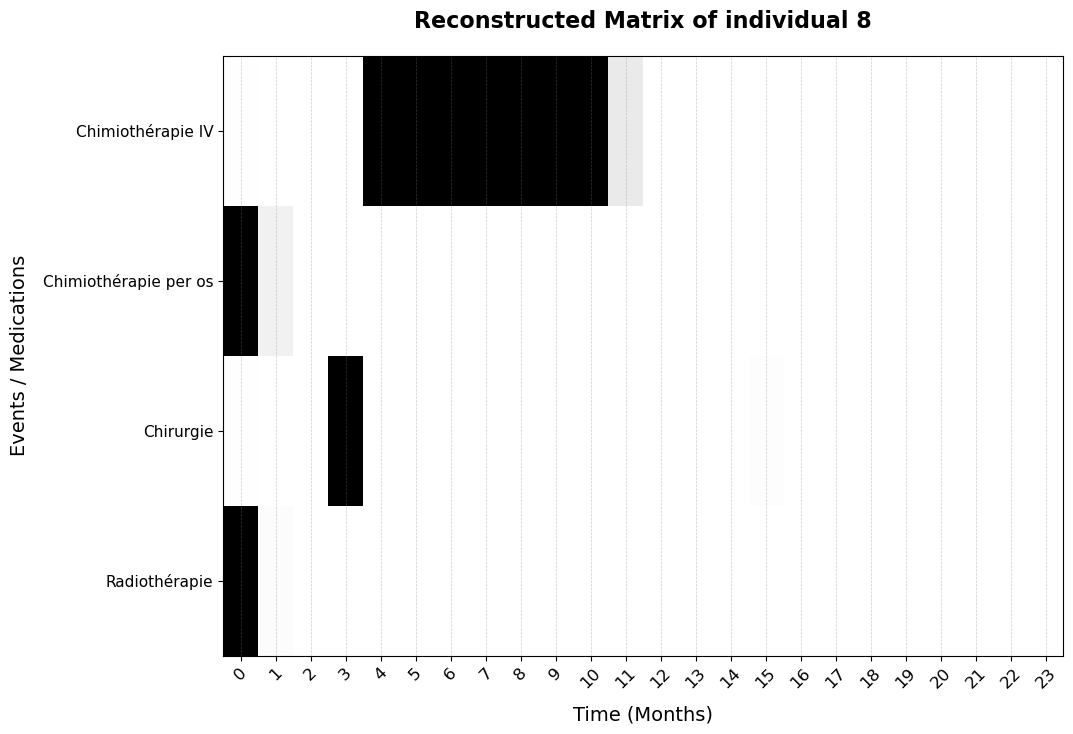

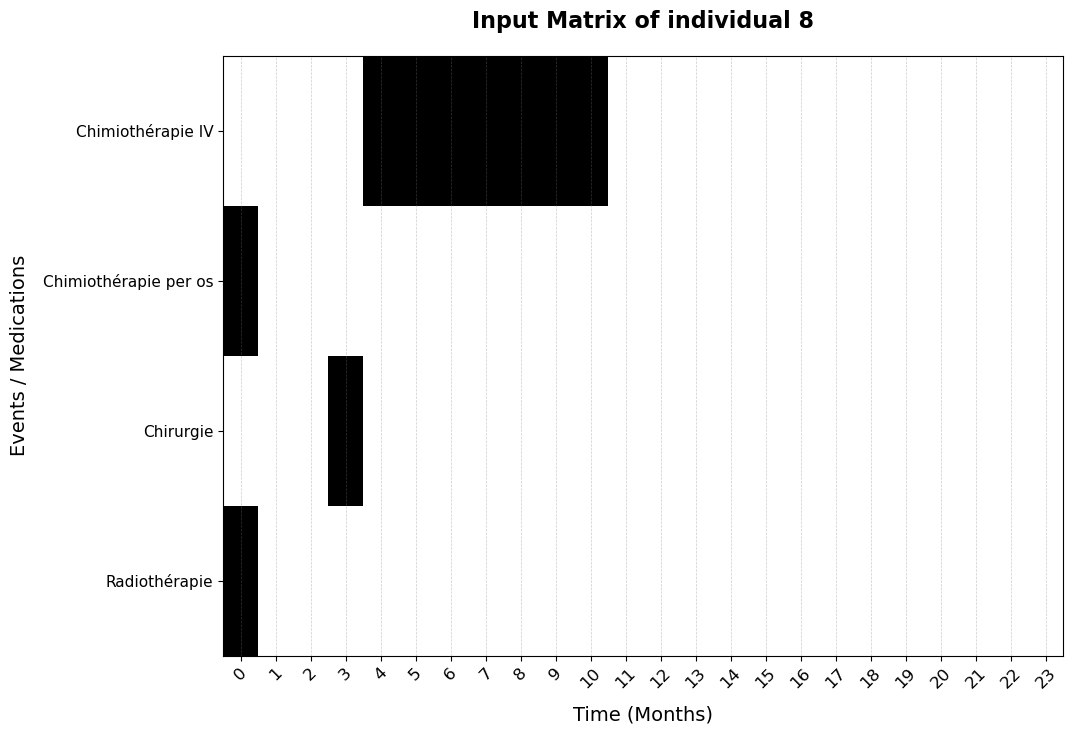

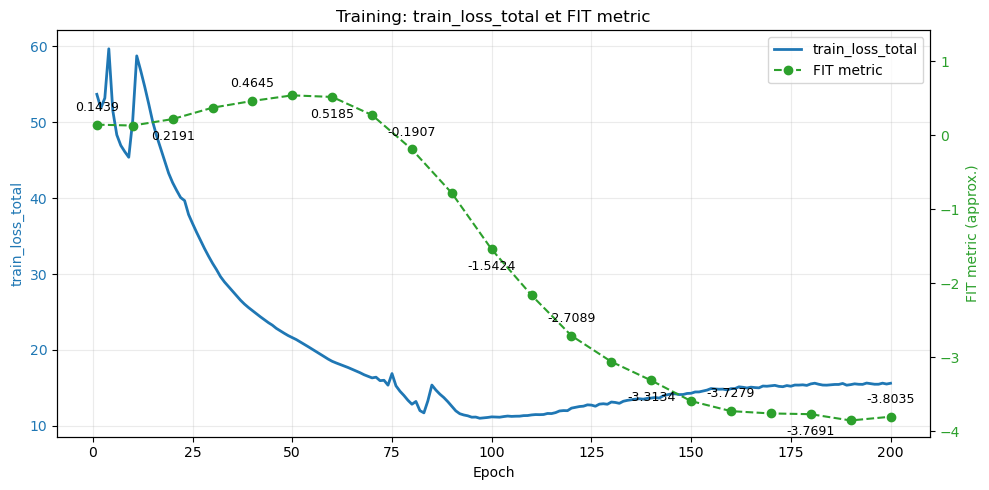


Configuration #2 : rank=5, twl=2, reg_ns=0.5, reg_s=0.5, learning rate=0.01
  best_fit_metric=0.5313, final_fit_metric=-3.6565
Decomposed into 1336 pathways with rank 5 and time window length 2
Success rate for the entire dataset: -3.6486


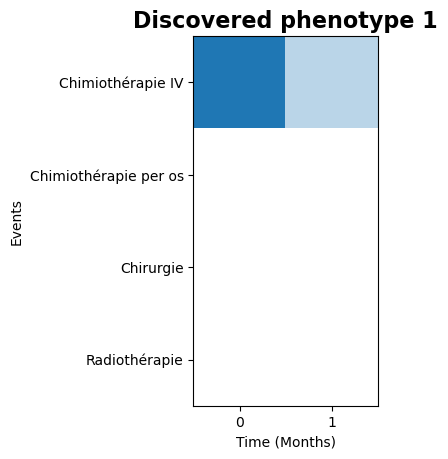

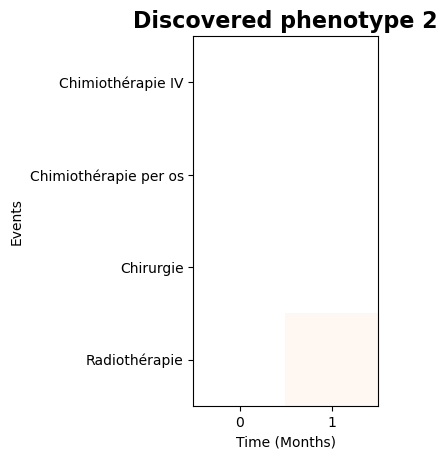

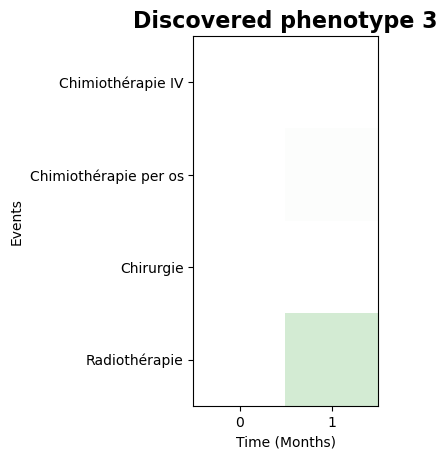

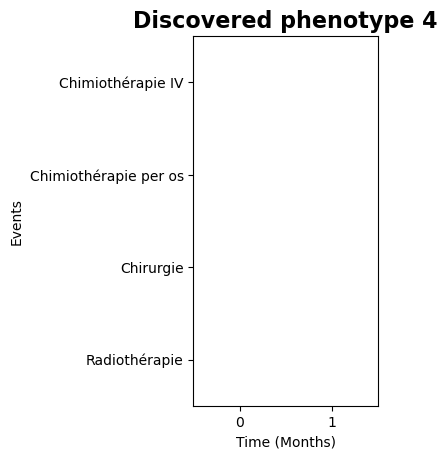

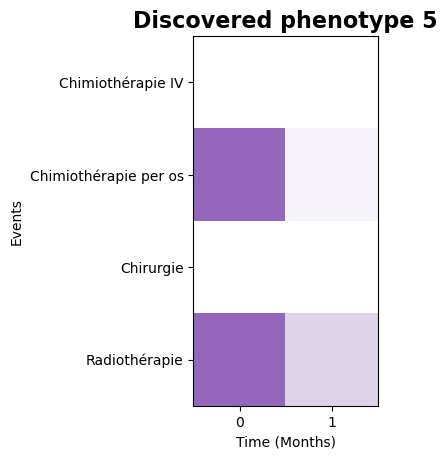

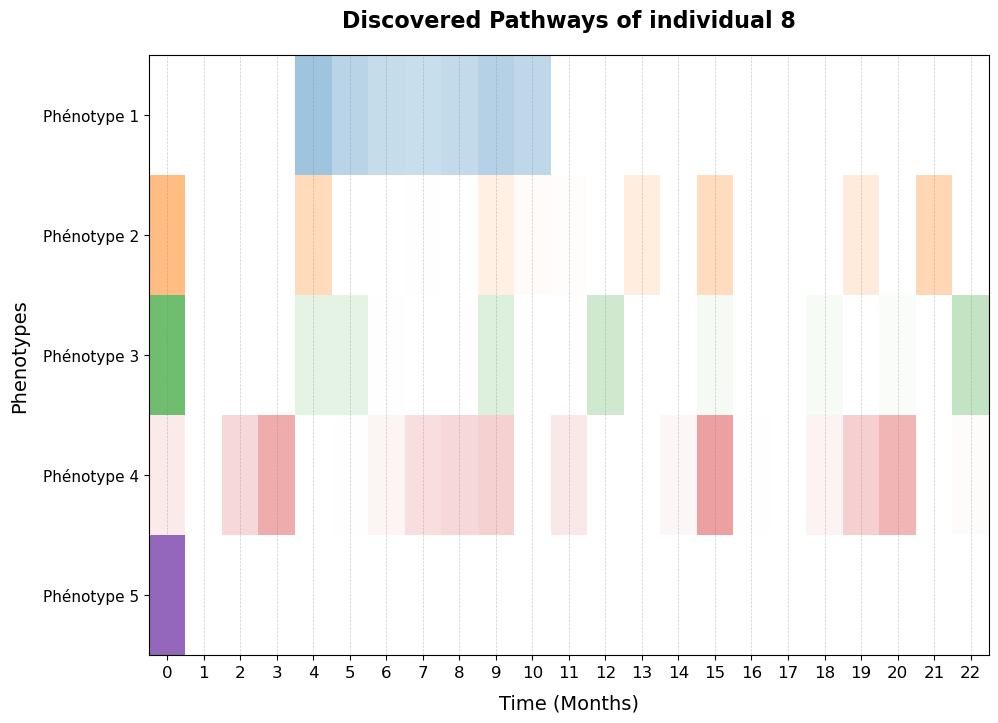

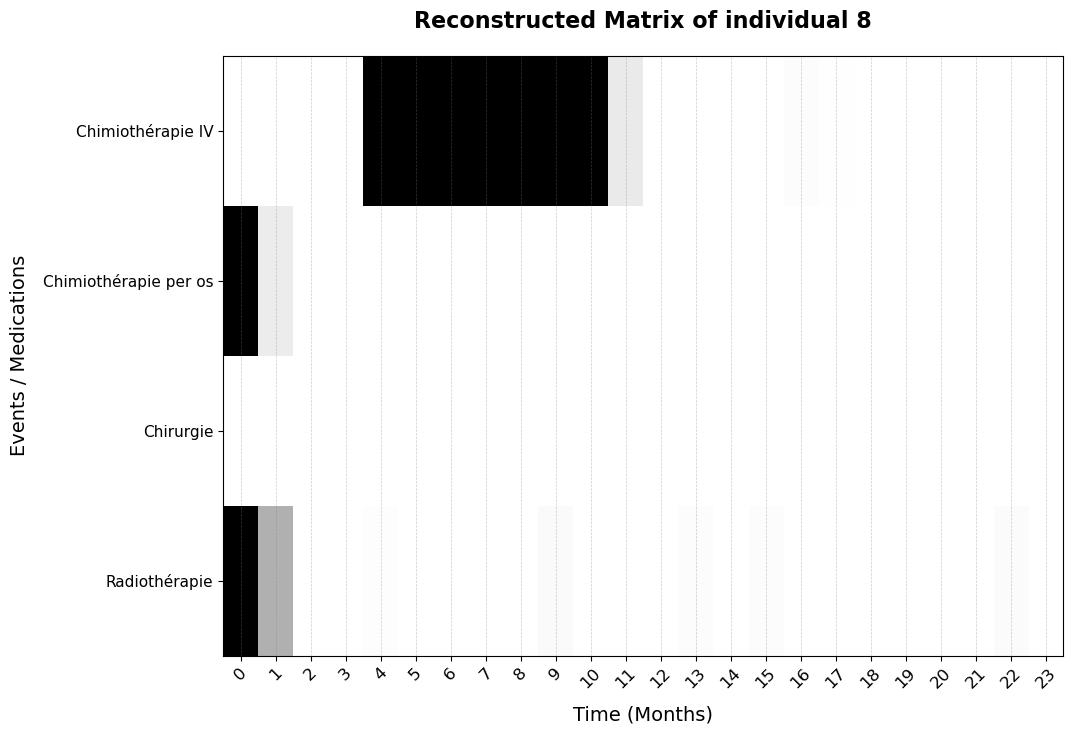

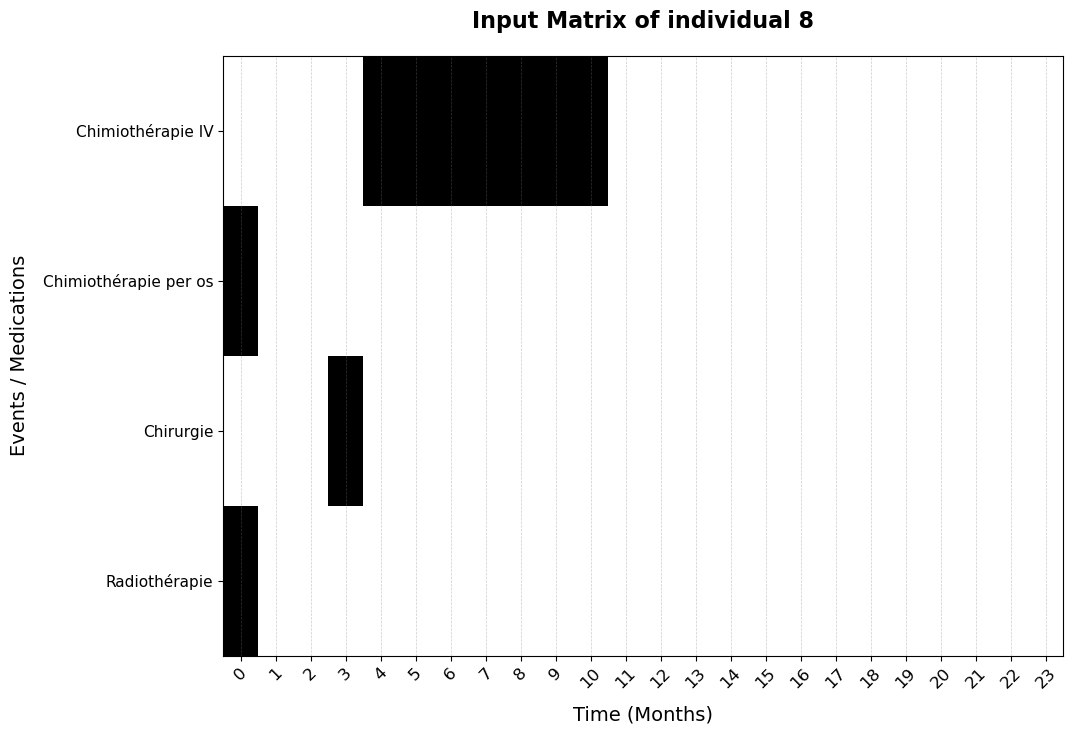

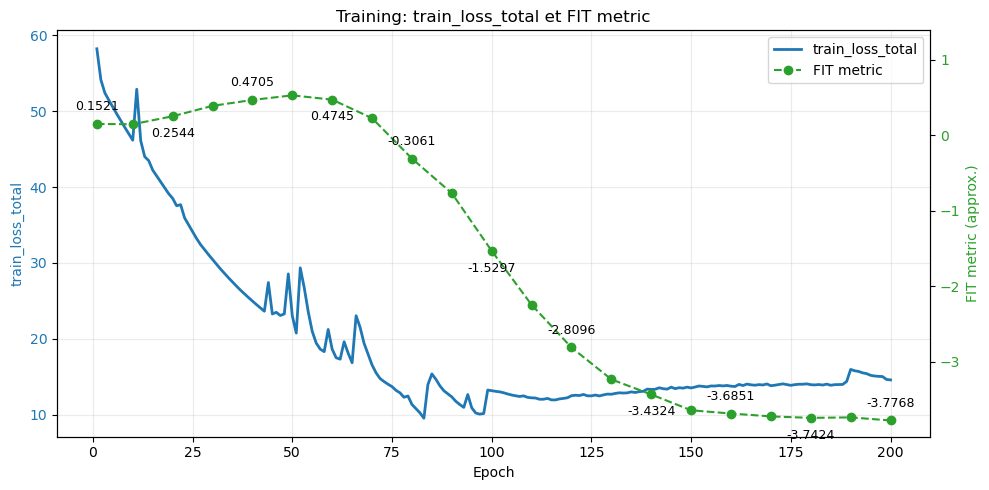


Configuration #3 : rank=3, twl=2, reg_ns=0.5, reg_s=0.5, learning rate=0.01
  best_fit_metric=0.5290, final_fit_metric=-3.6461
Decomposed into 1336 pathways with rank 3 and time window length 2
Success rate for the entire dataset: -3.6531


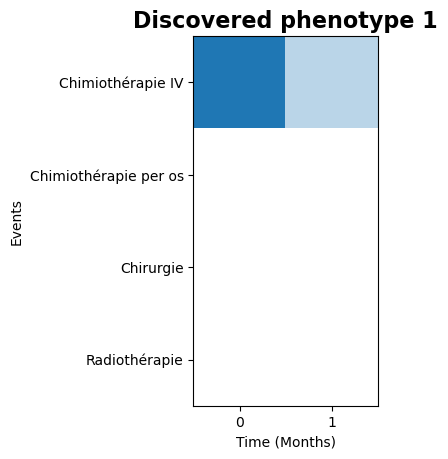

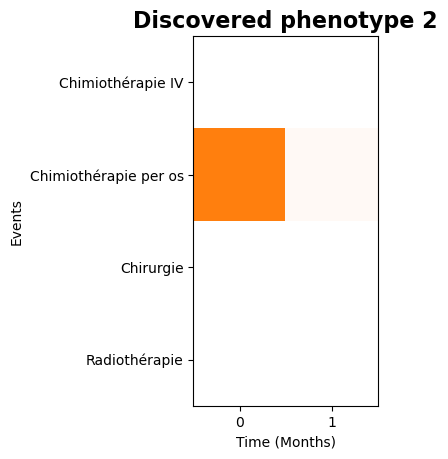

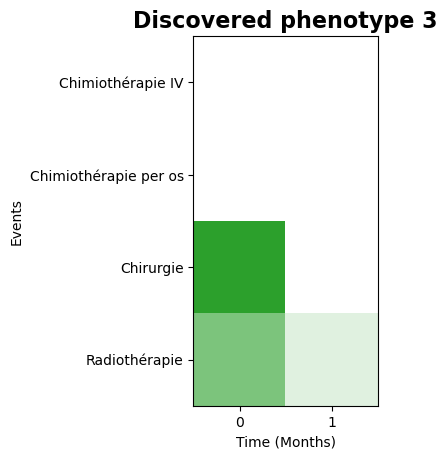

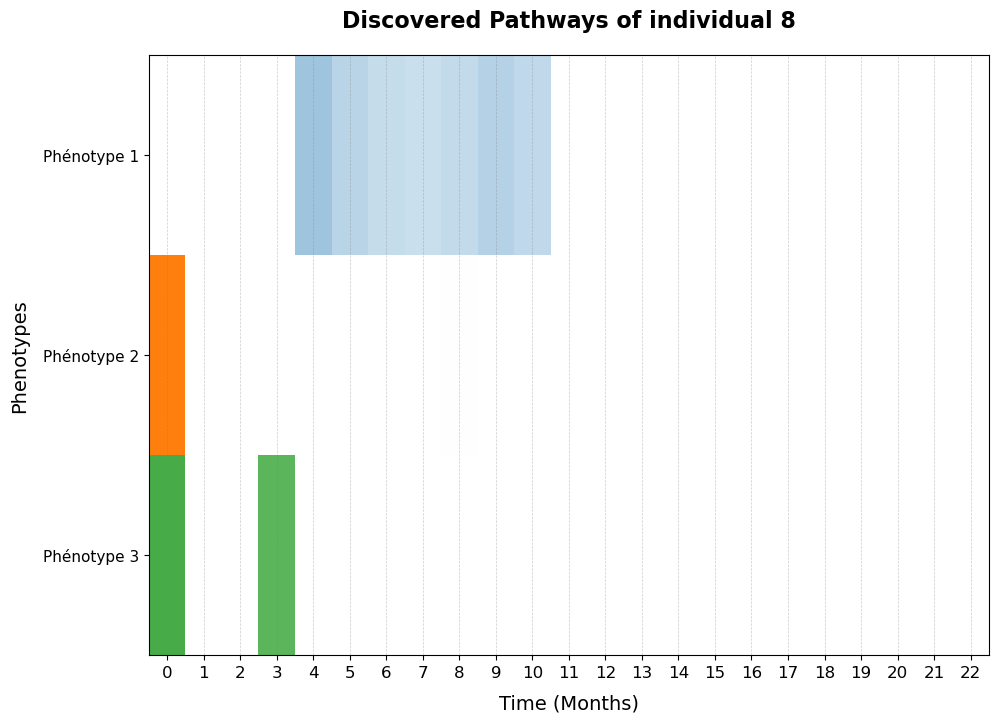

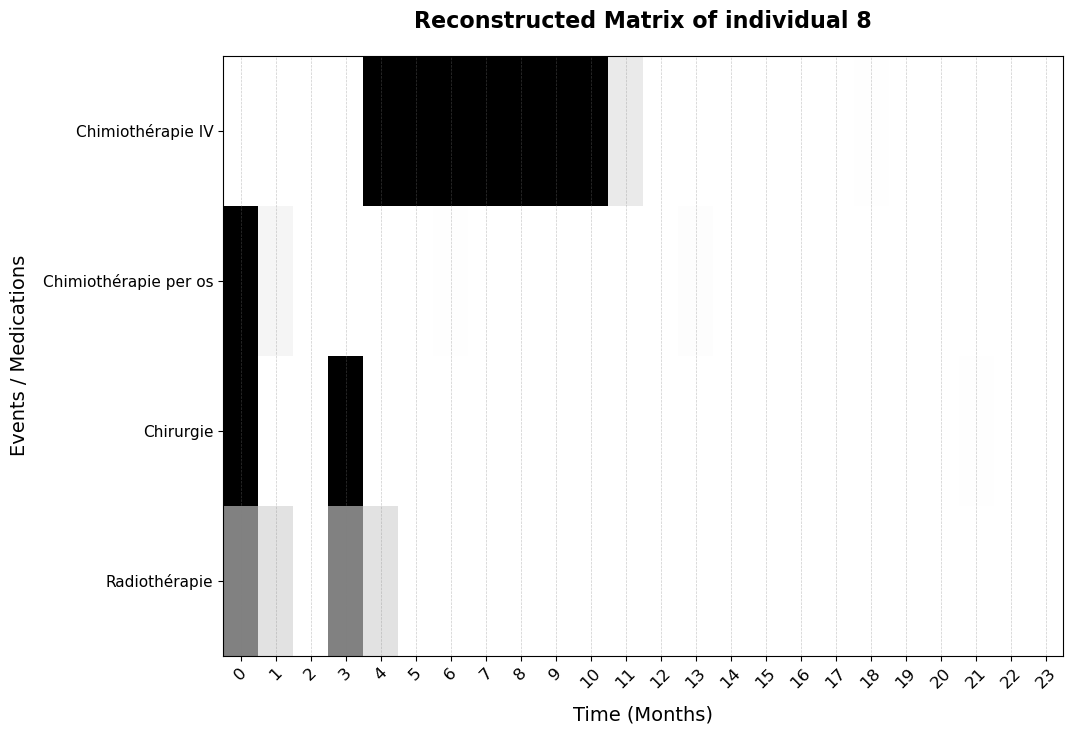

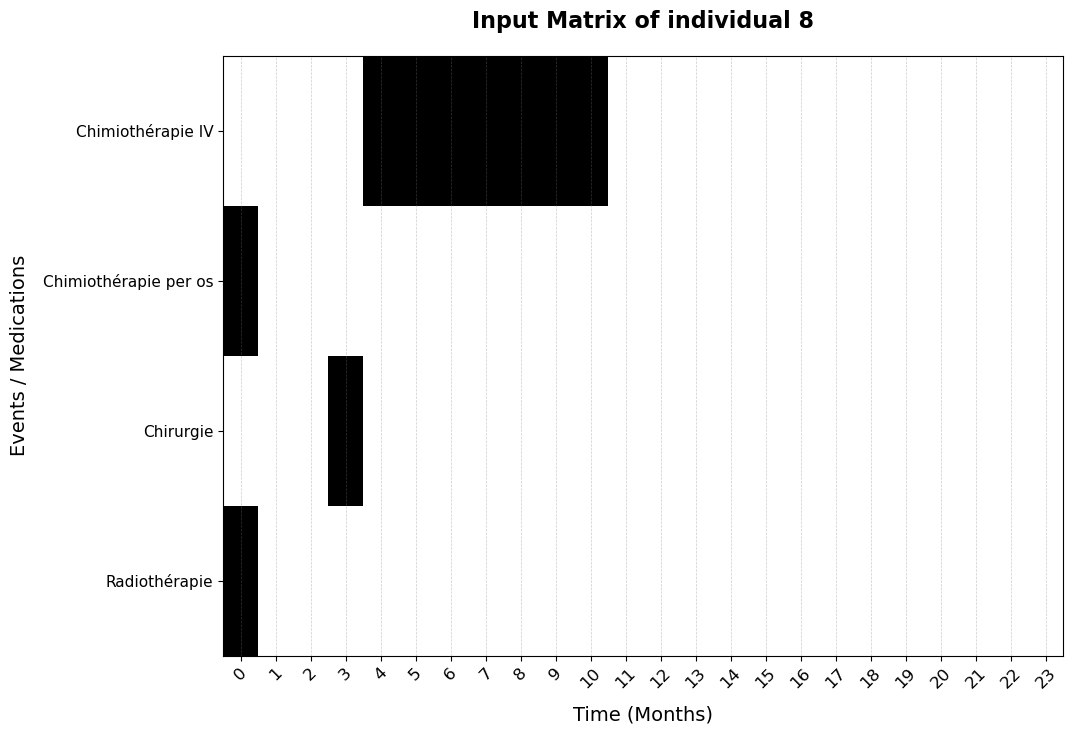

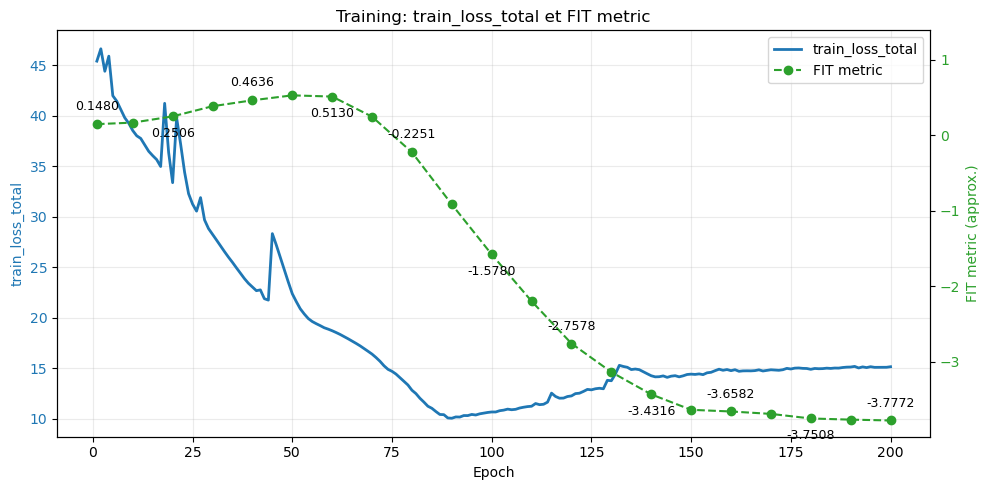

In [ ]:
best1 = results_df1.iloc[0]
tca_best1 = best1['tca_trial']

# Phénotypes et reconstruction
tca_best1.analyzer.get_decomposition_results(
    labels=tca.label_to_encoded,
    id=8,
    time_unit='Months',
)

# Courbe d'entraînement
plot_training_history(best1)

# Diversité phénotypique
print_diversity(best1)

On observe que $\text{FIT}_X$ augmente jusqu'à un maximum autour de l'epoch 60 à eviron $0{,}5$, puis se dégrade progressivement jusqu'à devenir négative en fin d'entraînement, alors que la loss continue de décroître, mais on observe quelques pics qui pourrait être un signe que notre taux d'apprentissage est trop élevé. Ce comportement, ainsi que la forte hétérogénéité des reconstructions individuelles, nous conduit à introduire un mécanisme d'early stopping et à réduire le taux d'apprentissage.

Toutefois, malgré les mauvais résultats pour $\text{FIT}_X$, on observe que nos phénotypes sont très marqués et interprétables et la reconstruction du patient n°8 est très bonne

On remarque aussi que notre diversité des phénotypes est très bonne, elle est égale à 1, tous nos phénotypes sont bien distincts.

In [ ]:
tca_best1.analyzer.get_decomposition_results(
    labels=tca.label_to_encoded,
    id=20,
    time_unit='Months',
)


Configuration #1 : rank=4, twl=2, reg_ns=0.5, reg_s=0.5, learning rate=0.01
  best_fit_metric=0.5399, final_fit_metric=-3.7408
Phenotype diversity (average 1 - cosine): 1.000000



,Phenotype_1,Phenotype_2,Phenotype_3,Phenotype_4
Phenotype_1,0.0,1.0,1.0,1.0
Phenotype_2,1.0,0.0,1.0,1.0
Phenotype_3,1.0,1.0,0.0,1.0
Phenotype_4,1.0,1.0,1.0,0.0



Configuration #2 : rank=5, twl=2, reg_ns=0.5, reg_s=0.5, learning rate=0.01
  best_fit_metric=0.5313, final_fit_metric=-3.6565
Phenotype diversity (average 1 - cosine): 0.877095



,Phenotype_1,Phenotype_2,Phenotype_3,Phenotype_4,Phenotype_5
Phenotype_1,0.0,1.000000,1.000000,1.0,1.000000
Phenotype_2,1.0,0.000000,0.002171,1.0,0.885230
Phenotype_3,1.0,0.002171,0.000000,1.0,0.883545
Phenotype_4,1.0,1.000000,1.000000,0.0,1.000000
Phenotype_5,1.0,0.885230,0.883545,1.0,0.000000



Configuration #3 : rank=3, twl=2, reg_ns=0.5, reg_s=0.5, learning rate=0.01
  best_fit_metric=0.5290, final_fit_metric=-3.6461
Phenotype diversity (average 1 - cosine): 0.999997



...

,Phenotype_1,Phenotype_2
Phenotype_1,0.0,1.0
Phenotype_2,1.0,0.0



Configuration #11 : rank=5, twl=4, reg_ns=0.5, reg_s=0.5, learning rate=0.01
  best_fit_metric=0.4442, final_fit_metric=-2.8492
Phenotype diversity (average 1 - cosine): 0.999924



,Phenotype_1,Phenotype_2,Phenotype_3,Phenotype_4,Phenotype_5
Phenotype_1,0.0,1.0,1.000000,1.000000,1.0
Phenotype_2,1.0,0.0,1.000000,1.000000,1.0
Phenotype_3,1.0,1.0,0.000000,0.999243,1.0
Phenotype_4,1.0,1.0,0.999243,0.000000,1.0
Phenotype_5,1.0,1.0,1.000000,1.000000,0.0



Configuration #12 : rank=2, twl=3, reg_ns=0.5, reg_s=0.5, learning rate=0.01
  best_fit_metric=0.4266, final_fit_metric=-3.0782
Phenotype diversity (average 1 - cosine): 1.000000



,Phenotype_1,Phenotype_2
Phenotype_1,0.0,1.0
Phenotype_2,1.0,0.0


Toutefois, quand on observe la reconstruction d'un autre patient, celle-ci est beaucoup moins bonne et explique la mauvaise fit metric.

### 4.2. Réduction du taux d'apprentissage avec early stopping

On conserve la configuration $R=4$, $\omega=2$ et on teste deux taux d'apprentissage plus faibles : $5 \times 10^{-5}$ et $10^{-4}$, avec early stopping activé sur 500 epochs.

In [ ]:
n_epochs       = 500
r, w           = 4, 2
s, ns          = 0.5, 0.5
learning_rates = [5e-5, 1e-4]
results2       = []

for lr in learning_rates:
    results2.append(run_swotted_trial(
        timed_event_structure, r, w,
        reg_ns=ns, reg_s=s, lr=lr, n_epochs=n_epochs,
        early_stopping=True,
    ))

results_df2 = build_results_df(results2)
display(results_df2.drop(columns='tca_trial'))

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.



rank=4, twl=2, reg_ns=0.5, reg_s=0.5, learning_rate=5e-05
Dataset :
data shape:  (20435, 3)
state coding:
    label  label encoded
0      0              0
1      1              1
2      2              2
3      3              3


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model        | SlidingWindow | 0      | train | 0    
  | other params | n/a           | 32     | n/a   | n/a  
--------------------------------------


 -> Starting training


c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


...

c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Epoch 1/500 : - train_loss_Ph: 99.640114 - train_loss_W: 110.901756 - train_loss_total: 210.541870 - duration: 3.41s - FIT metric: -6.1757
    early stopping: Metric fit_metric initialized at -6.176.
    checkpoint: New best FIT metric = -6.1757 at epoch 1.
Epoch 2/500 : - train_loss_Ph: 98.425995 - train_loss_W: 109.823380 - train_loss_total: 208.249374 - duration: 3.44s
Epoch 3/500 : - train_loss_Ph: 97.227608 - train_loss_W: 108.757423 - train_loss_total: 205.985031 - duration: 3.21s
Epoch 4/500 : - train_loss_Ph: 96.013397 - train_loss_W: 107.675766 - train_loss_total: 203.689163 - duration: 3.27s
Epoch 5/500 : - train_loss_Ph: 94.781212 - train_loss_W: 106.576782 - train_loss_total: 201.357994 - duration: 3.26s
Epoch 6/500 : - train_loss_Ph: 93.539986 - train_loss_W: 105.469017 - train_loss_total: 199.009003 - duration: 3.21s
Epoch 7/500 : - train_loss_Ph: 92.321671 - train_loss_W: 104.380539 - train_loss_total: 196.702209 - duration: 3.25s
Epoch 8/500 : - train_loss_Ph: 91.086853

,rank,time_window_length,reg_term_ns,reg_term_s,learning_rate,epochs_run,best_fit_metric,best_fit_epoch,final_fit_metric,elapsed_s,tca_trial
0,4,2,0.5,0.5,0.00010,250,0.012727,150,0.022226,2685.67,<trajectoryclusteringanalysis.tca.TCA object a...
1,4,2,0.5,0.5,0.00005,370,0.006403,270,0.013840,3418.88,<trajectoryclusteringanalysis.tca.TCA object a...



Meilleure configuration candidate:
{'rank': 4, 'time_window_length': 2, 'reg_term_ns': 0.5, 'reg_term_s': 0.5, 'learning_rate': 0.0001, 'epochs_run': 250, 'best_fit_metric': 0.012727398689882707, 'best_fit_epoch': 150, 'final_fit_metric': 0.02222595899252655, 'elapsed_s': 2685.67, 'tca_trial': <trajectoryclusteringanalysis.tca.TCA object at 0x000001DE19DAC5B0>}


Le learning rate qui donne les meilleurs résultats est $10^{-4}$
Nous pouvons maintenant observer les plots de la `train_loss` avec $\text{FIT}_X$ ainsi que les phénotypes obtenus pour la meilleure configuration.


Configuration #1 : rank=4, twl=2, reg_ns=0.5, reg_s=0.5, learning rate=0.0001
  best_fit_metric=0.0127, final_fit_metric=0.0222
Decomposed into 1336 pathways with rank 4 and time window length 2
Success rate for the entire dataset: 0.0232


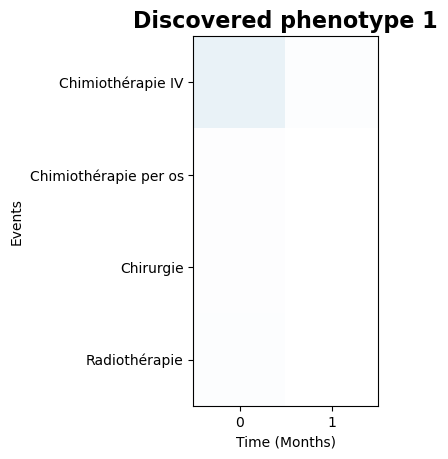

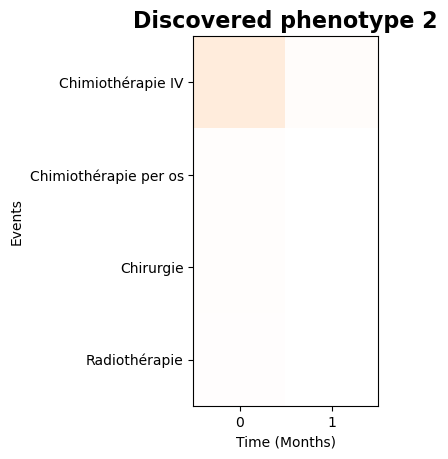

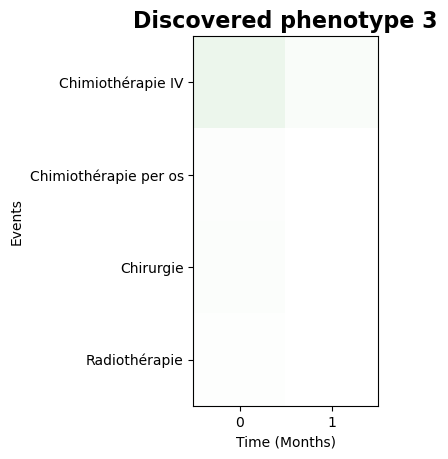

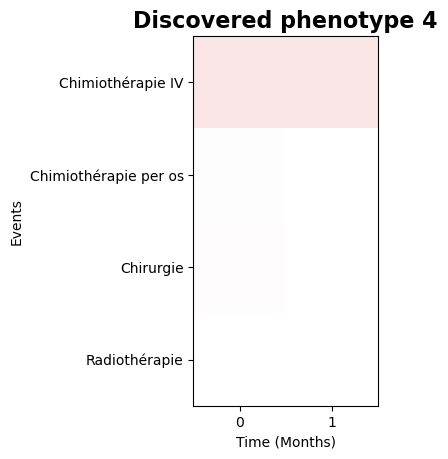

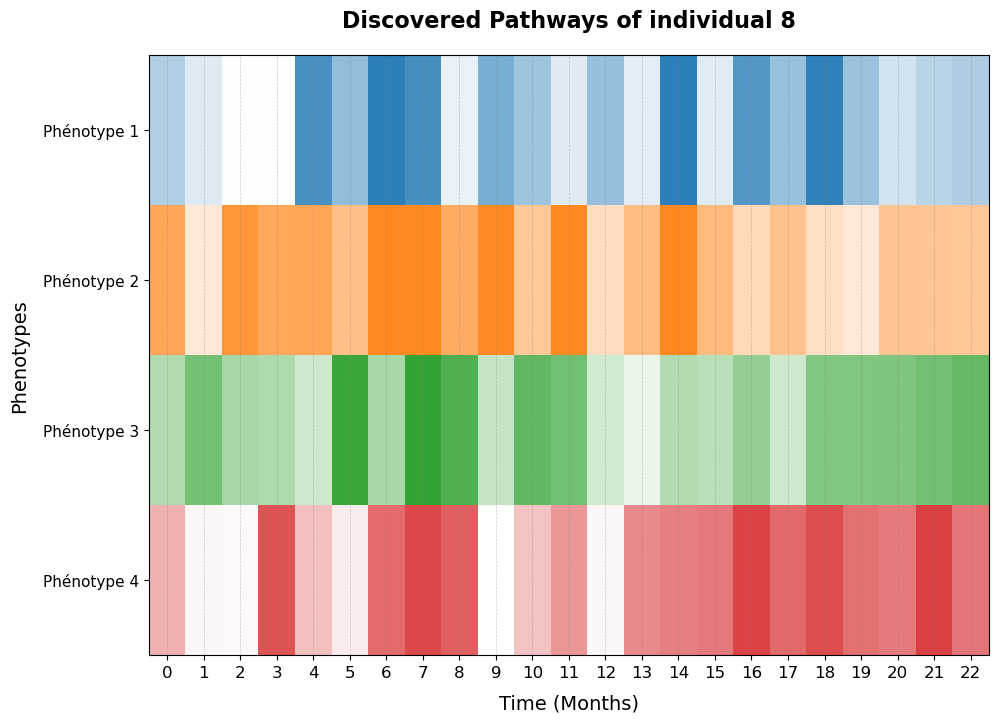

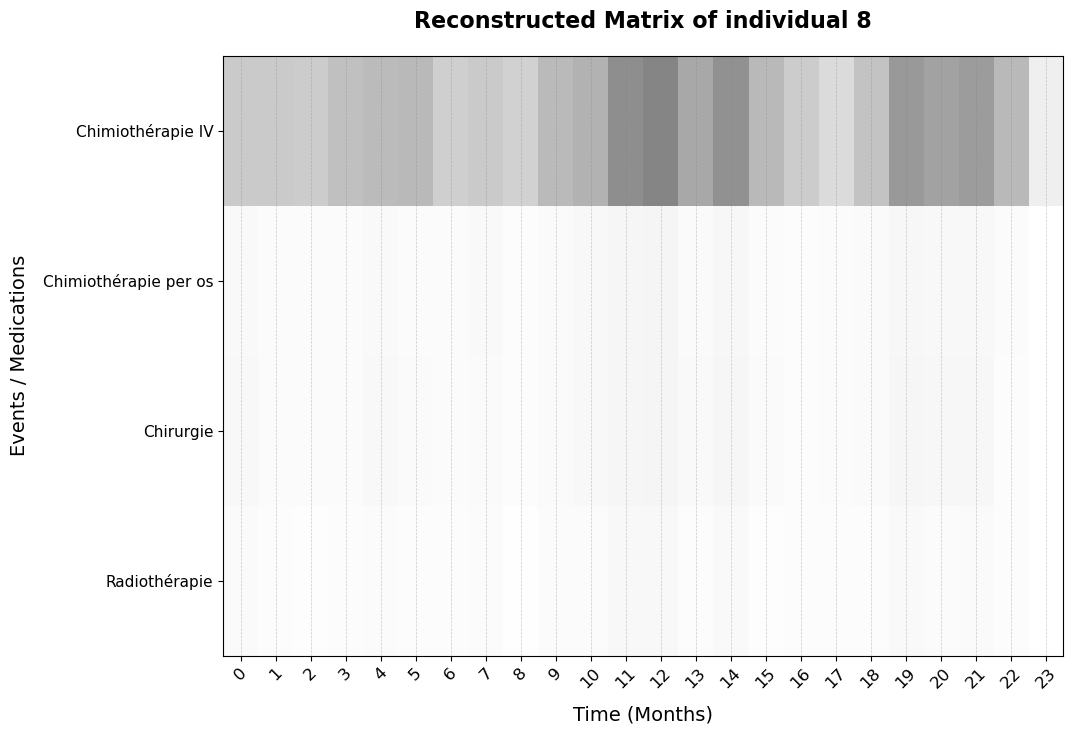

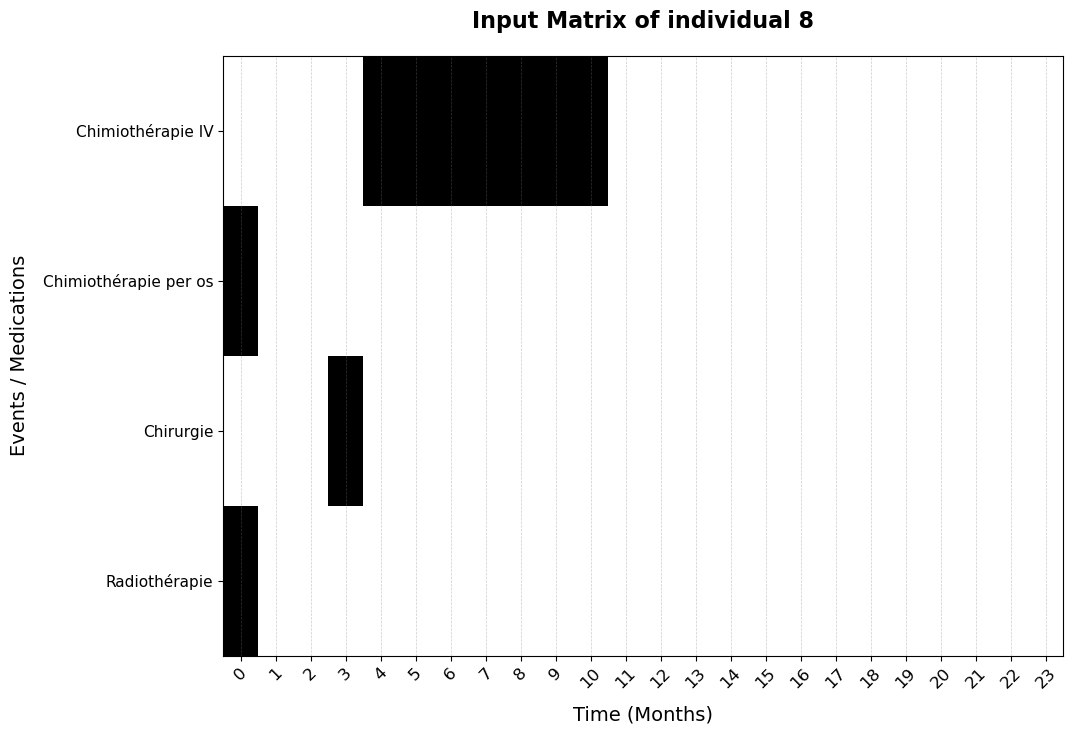

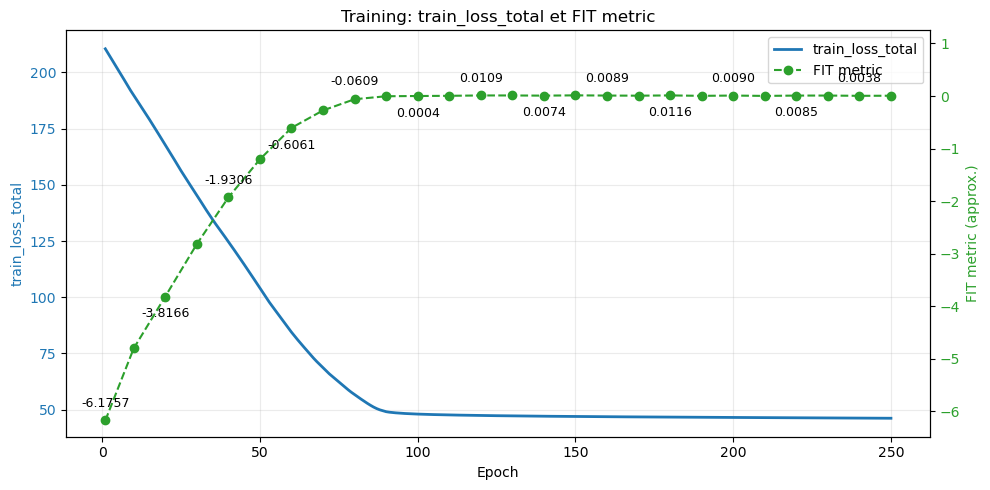

In [16]:
for i, row in results_df2.head(1).iterrows():
    print('\n' + '=' * 90)
    print(f"Configuration #{i+1} : rank={row['rank']}, twl={row['time_window_length']}, "
          f"reg_ns={row['reg_term_ns']}, reg_s={row['reg_term_s']}, learning rate={row['learning_rate']}")
    print(f"  best_fit_metric={row['best_fit_metric']:.4f}, final_fit_metric={row['final_fit_metric']:.4f}")
    
    tca_trial = row['tca_trial']
    labels = timed_event_structure['Event'].unique()
    id_patient = timed_event_structure['ID_PATIENT'].iloc[0]
    
    tca_trial.analyzer.get_decomposition_results(
        labels=tca.label_to_encoded,
        id=8,
        time_unit="Months"
    )

    history = getattr(tca_trial.analyzer, 'training_history', None)
    if not history or len(history.get('epoch', [])) == 0:
        raise ValueError("Aucun historique d'entrainement disponible. Execute d'abord la cellule d'entrainement.")
    
    epochs = history['epoch']
    train_loss_total = history['train_loss_total']
    fit_epochs = history['fit_metric_points_epoch']
    fit_values = history['fit_metric_points_value']

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(epochs, train_loss_total, color='tab:blue', linewidth=2, label='train_loss_total')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('train_loss_total', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(alpha=0.25)

    ax2 = ax1.twinx()
    if len(fit_epochs) > 0:
        ax2.plot(fit_epochs, fit_values, color='tab:green', marker='o', linestyle='--', label='FIT metric')
        for i, (x, y) in enumerate(zip(fit_epochs, fit_values)):
            if i % 2 == 0: 
                y_offset = 10 if i % 4 == 0 else -15 
                ax2.annotate(f"{y:.4f}", (x, y), textcoords='offset points', xytext=(0, y_offset), ha='center', fontsize=9)

        fit_min = min(fit_values)
        fit_max = max(fit_values)
        fit_span = max(fit_max - fit_min, 1e-6)
        ax2.set_ylim(bottom=fit_min - 0.05 * fit_span, top=fit_max + 0.20 * fit_span)

    ax2.set_ylabel('FIT metric (approx.)', color='tab:green')
    ax2.tick_params(axis='y', labelcolor='tab:green')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
    plt.title('Training: train_loss_total et FIT metric')
    plt.tight_layout()
    plt.show()

Pour un learning rate 100 fois plus petit, la loss n'a plus les pics qu'on observait précedemment et la fit metric ne chute plus à partir d'une certaine epoch, elle augmente jusqu'à atteindre un maximum aux alentours de 0.01, puis elle atteint plateau.

In [43]:
for i, row in results_df2.iterrows():
    print('\n' + '=' * 90)
    print(f"Configuration #{i+1} : rank={row['rank']}, twl={row['time_window_length']}, "
          f"reg_ns={row['reg_term_ns']}, reg_s={row['reg_term_s']}, learning rate={row['learning_rate']}")
    print(f"  best_fit_metric={row['best_fit_metric']:.4f}, final_fit_metric={row['final_fit_metric']:.4f}")
    
    tca_trial = row['tca_trial']
    labels = timed_event_structure['Event'].unique()
    id_patient = timed_event_structure['ID_PATIENT'].iloc[0]
    
    Ph_tensor = tca_trial.analyzer.model.Ph.detach()

    div_value, pairwise_div = phenotype_diversity(Ph_tensor)

    print(f"Phenotype diversity (average 1 - cosine): {div_value:.6f}\n")

    # Affichage sous forme de DataFrame (tableau)
    col_names = [f"Phenotype_{i+1}" for i in range(pairwise_div.shape[0])]
    pairwise_div_df = pd.DataFrame(
        pairwise_div.cpu().numpy(),
        index=col_names,
        columns=col_names,
    )

    display(pairwise_div_df)


Configuration #1 : rank=4, twl=2, reg_ns=0.5, reg_s=0.5, learning rate=0.0001
  best_fit_metric=0.0127, final_fit_metric=0.0222
Phenotype diversity (average 1 - cosine): 0.089741



,Phenotype_1,Phenotype_2,Phenotype_3,Phenotype_4
Phenotype_1,0.000000,0.001997,0.023020,0.201285
Phenotype_2,0.001997,0.000000,0.021693,0.187992
Phenotype_3,0.023020,0.021693,0.000000,0.102461
Phenotype_4,0.201285,0.187992,0.102461,0.000000



Configuration #2 : rank=4, twl=2, reg_ns=0.5, reg_s=0.5, learning rate=5e-05
  best_fit_metric=0.0064, final_fit_metric=0.0138
Phenotype diversity (average 1 - cosine): 0.039217



,Phenotype_1,Phenotype_2,Phenotype_3,Phenotype_4
Phenotype_1,0.000000,0.006543,0.080521,0.064085
Phenotype_2,0.006543,0.000000,0.047543,0.034109
Phenotype_3,0.080521,0.047543,0.000000,0.002503
Phenotype_4,0.064085,0.034109,0.002503,0.000000


### 4.3. Etude sur de très petits termes de régularisation avec early stopping (sur 500 epochs)

Nous allons maintenant essayer de faire varier les termes de régularisation sur de très petites valeurs.

- le terme de non-succession $\gamma \in \{5 \times 10^{-3}, 10^{-3}, 5 \times 10^{-2} \}$
- le terme de sparsité $\alpha$ : on fait varier $\alpha \in \{10^{-5}, 10^{-4}\}$

In [23]:
n_epochs = 500
r = 4
w = 2
sparsities = [1e-5, 5e-3, 1e-1]
non_succession = [1e-5, 5e-3, 1e-1]
lr = 1e-4
results3 = []

for ns in non_succession:
    for s in sparsities:
        print('\n' + '=' * 90)
        print(
        f"rank={r}, twl={w}, reg_ns={ns}, reg_s={s}, learning_rate={lr}"
        )

        tca_trial = TCA(
            data=timed_event_structure,
            index_col='ID_PATIENT',
            time_col='Time',
            event_col='Event',
            mode='multidimensional',
        )
        tca_trial.analyzer.transform_time_event_structure_to_tensor()
        tensor_trial = tca_trial.analyzer.get_tensor()
                
        t0 = time.perf_counter()
        tca_trial.analyzer.fit_swotted_decomposition(
            tensor_trial,
            r,
            w,
            ns,
            s,
            metric,
            lr,
            n_epochs,
            fit_metric_every_n_epochs=10,
                fit_metric_eval_max_patients=64,
                num_workers=8,
                early_stopping_patience=10,
                early_stopping_min_delta=1e-4,
                early_stopping_monitor='fit_metric',
            )
                
        elapsed = time.perf_counter() - t0

        hist = getattr(tca_trial.analyzer, 'training_history', {}) or {}
        best_fit = hist.get('best_fit_metric', None)
        best_fit_epoch = hist.get('best_fit_metric_epoch', None)
        final_fit = hist.get('final_fit_metric', None)
        epochs_run = len(hist.get('epoch', []))

        results3.append({
            'rank': r,
            'time_window_length': w,
            'reg_term_ns': ns,
            'reg_term_s': s,
            'learning_rate': lr,
            'epochs_run': epochs_run,
            'best_fit_metric': best_fit,
            'best_fit_epoch': best_fit_epoch,
            'final_fit_metric': final_fit,
            'elapsed_s': round(elapsed, 2),
            'tca_trial': tca_trial
        })

results_df3 = pd.DataFrame(results3)
if not results_df3.empty:
    results_df3 = results_df3.sort_values(
        by=['best_fit_metric', 'final_fit_metric'],
        ascending=False,
        na_position='last'
    ).reset_index(drop=True)

print('\nTop configurations (FIT):')
display(results_df3)

if not results_df3.empty:
    best = results_df3.iloc[0].to_dict()
    print('\nMeilleure configuration candidate:')
    print(best)

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.



rank=4, twl=2, reg_ns=1e-05, reg_s=1e-05, learning_rate=0.0001
Dataset :
data shape:  (20435, 3)
state coding:
    label  label encoded
0      0              0
1      1              1
2      2              2
3      3              3


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\torch\utils\data\dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4 (`cpuset` is not taken into account), which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, 


 -> Starting training


Training: |          | 0/? [00:00<?, ?it/s]

...


 -> Starting training


Training: |          | 0/? [00:00<?, ?it/s]

Epoch 1/500 : - train_loss_Ph: 95.082268 - train_loss_W: 96.596977 - train_loss_total: 191.679245 - duration: 26.43s - FIT metric: -7.0941
    early stopping: Metric fit_metric initialized at -7.094.
    checkpoint: New best FIT metric = -7.0941 at epoch 1.
Epoch 2/500 : - train_loss_Ph: 94.105911 - train_loss_W: 95.647858 - train_loss_total: 189.753769 - duration: 4.49s
Epoch 3/500 : - train_loss_Ph: 93.141464 - train_loss_W: 94.709763 - train_loss_total: 187.851227 - duration: 4.41s
Epoch 4/500 : - train_loss_Ph: 92.162750 - train_loss_W: 93.757545 - train_loss_total: 185.920296 - duration: 3.93s
Epoch 5/500 : - train_loss_Ph: 91.181473 - train_loss_W: 92.802948 - train_loss_total: 183.984421 - duration: 4.61s
Epoch 6/500 : - train_loss_Ph: 90.215492 - train_loss_W: 91.862755 - train_loss_total: 182.078247 - duration: 4.30s
Epoch 7/500 : - train_loss_Ph: 89.250504 - train_loss_W: 90.922783 - train_loss_total: 180.173286 - duration: 4.10s
Epoch 8/500 : - train_loss_Ph: 88.271721 - tra

,rank,time_window_length,reg_term_ns,reg_term_s,learning_rate,epochs_run,best_fit_metric,best_fit_epoch,final_fit_metric,elapsed_s,tca_trial
0,4,2,0.00500,0.00500,0.0001,320,0.042424,300,0.048201,3437.85,<trajectoryclusteringanalysis.tca.TCA object a...
1,4,2,0.00500,0.10000,0.0001,240,0.042086,140,0.047673,3074.34,<trajectoryclusteringanalysis.tca.TCA object a...
2,4,2,0.00001,0.00500,0.0001,290,0.041431,190,0.047968,3291.04,<trajectoryclusteringanalysis.tca.TCA object a...
3,4,2,0.00001,0.00001,0.0001,350,0.040923,250,0.048141,3681.68,<trajectoryclusteringanalysis.tca.TCA object a...
4,4,2,0.00001,0.10000,0.0001,320,0.040464,220,0.047934,3410.67,<trajectoryclusteringanalysis.tca.TCA object a...
5,4,2,0.10000,0.00500,0.0001,310,0.039509,210,0.045552,3656.90,<trajectoryclusteringanalysis.tca.TCA object a...
6,4,2,0.00500,0.00001,0.0001,230,0.039071,130,0.045309,2867.34,<trajectoryclusteringanalysis.tca.TCA object a...
7,4,2,0.10000,0.00001,0.0001,280,0.037662,180,0.043544,3475.03,<trajectoryclusteringanalysis.tca.TCA object a...
8,4,2,0.10000,0.10000,0.0001,230,0.033882,130,0.040917,2961.45,<trajectoryclusteringanalysis.tca.TCA object a...



Meilleure configuration candidate:
{'rank': 4, 'time_window_length': 2, 'reg_term_ns': 0.005, 'reg_term_s': 0.005, 'learning_rate': 0.0001, 'epochs_run': 320, 'best_fit_metric': 0.04242365405355819, 'best_fit_epoch': 300, 'final_fit_metric': 0.0482012689670831, 'elapsed_s': 3437.85, 'tca_trial': <trajectoryclusteringanalysis.tca.TCA object at 0x000001DE0FC30790>}


Dans ce cas, la meilleure fit metric est atteinte pour $\alpha = \gamma = 5 \times 10^{-3}$


Configuration #1 : rank=4, twl=2, reg_ns=0.005, reg_s=0.005, learning rate=0.0001
  best_fit_metric=0.0424, final_fit_metric=0.0482
Decomposed into 1336 pathways with rank 4 and time window length 2
Success rate for the entire dataset: 0.0484


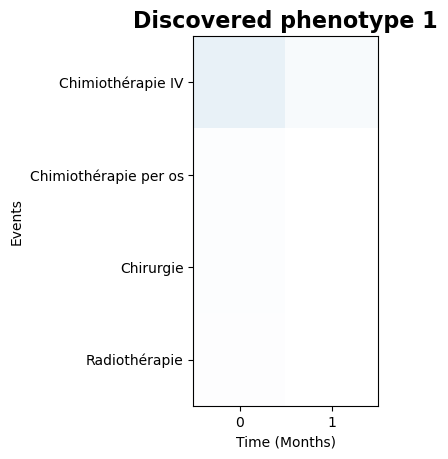

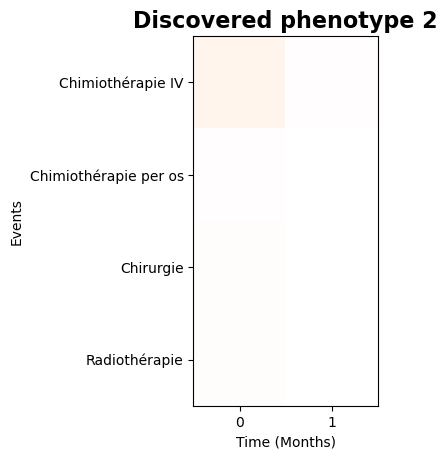

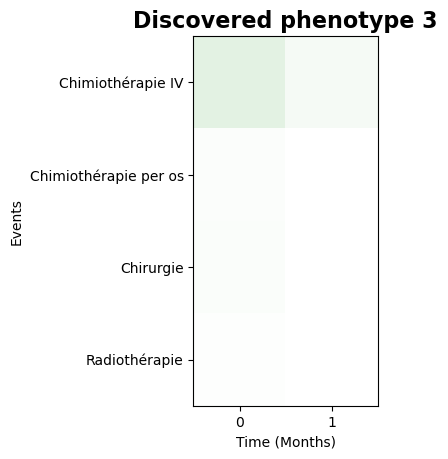

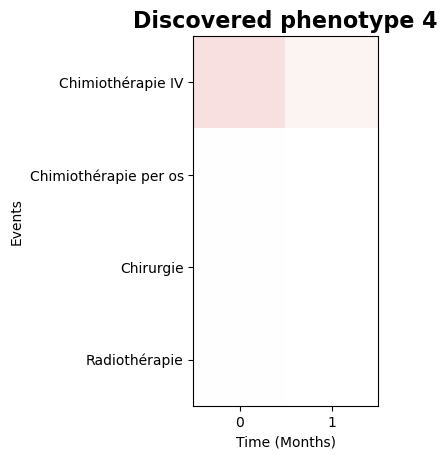

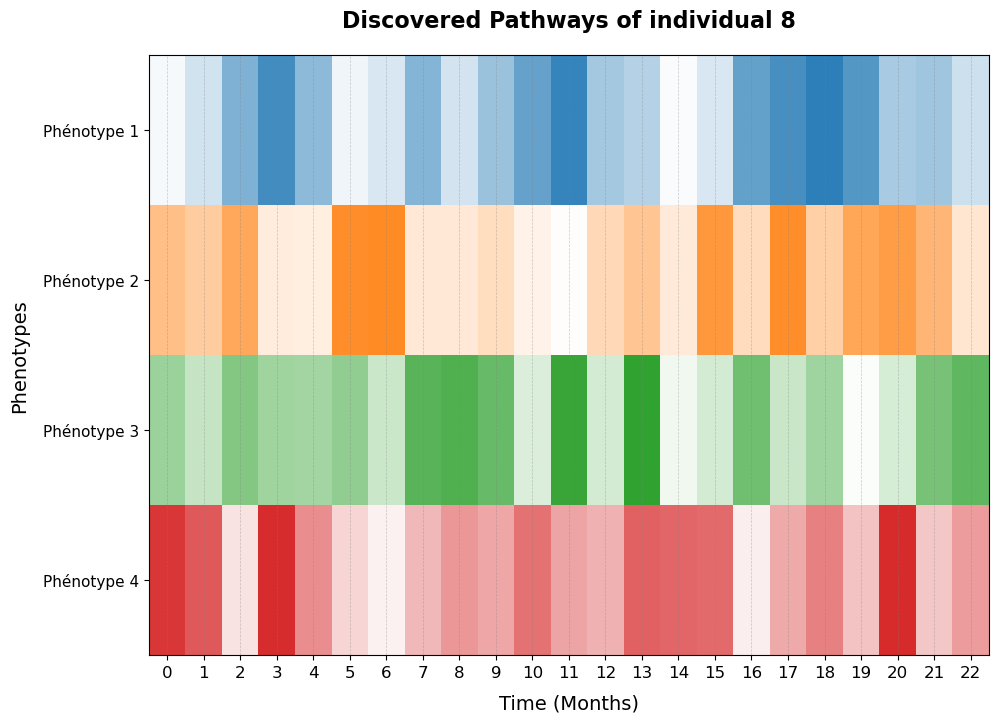

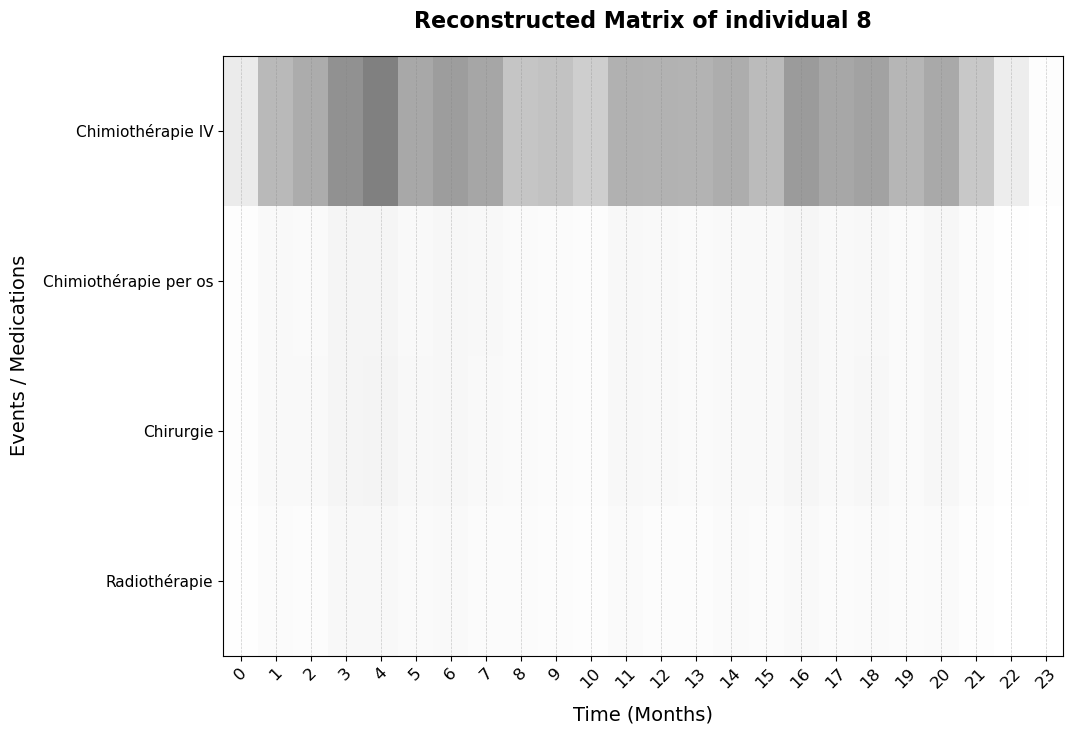

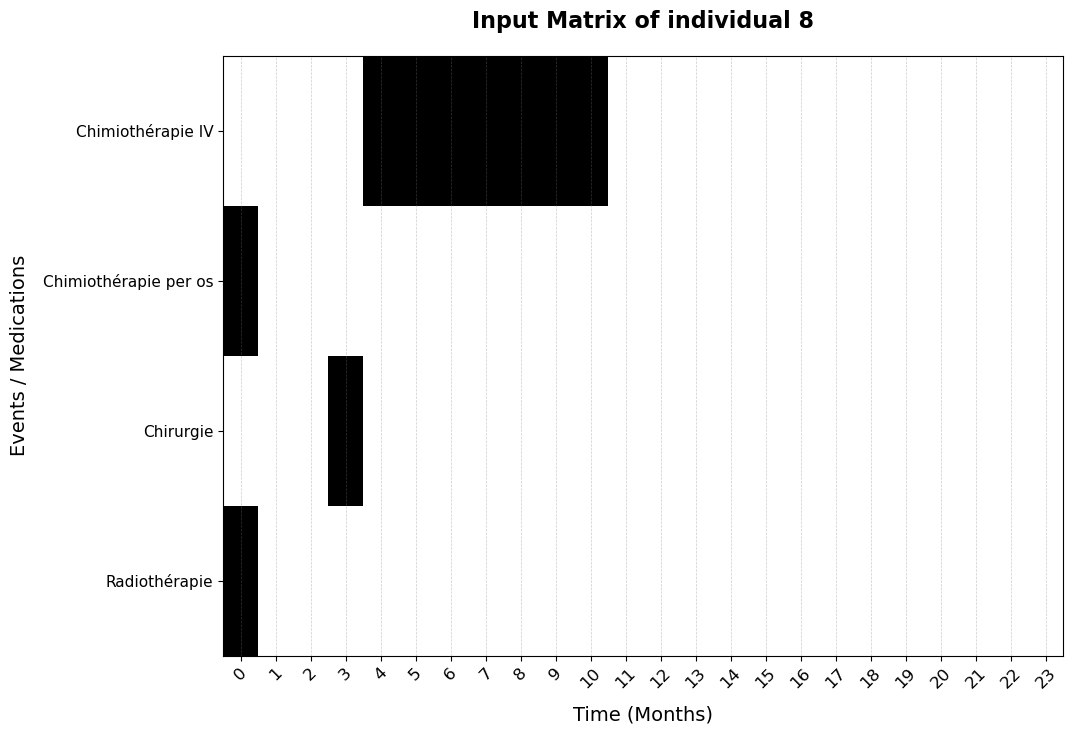

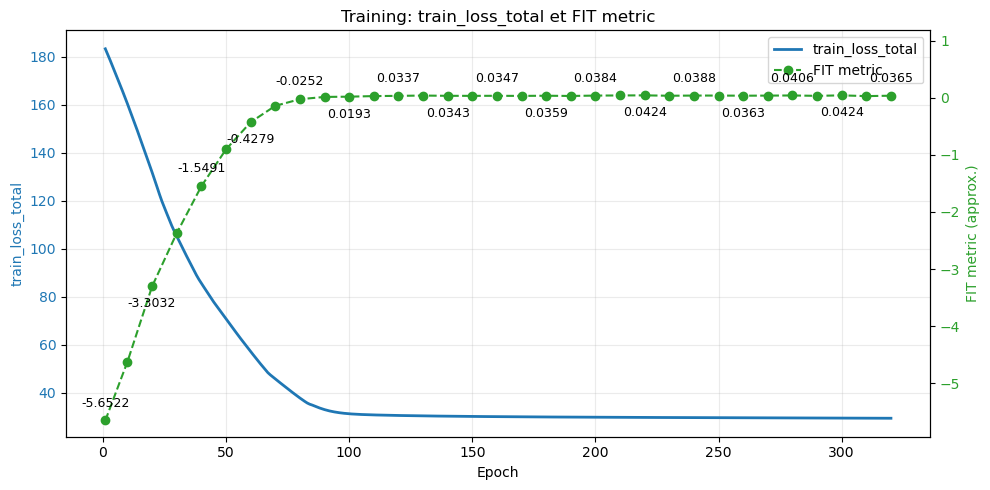

In [24]:
for i, row in results_df3.head(1).iterrows():
    print('\n' + '=' * 90)
    print(f"Configuration #{i+1} : rank={row['rank']}, twl={row['time_window_length']}, "
          f"reg_ns={row['reg_term_ns']}, reg_s={row['reg_term_s']}, learning rate={row['learning_rate']}")
    print(f"  best_fit_metric={row['best_fit_metric']:.4f}, final_fit_metric={row['final_fit_metric']:.4f}")
    
    tca_trial = row['tca_trial']
    labels = timed_event_structure['Event'].unique()
    id_patient = timed_event_structure['ID_PATIENT'].iloc[0]
    
    tca_trial.analyzer.get_decomposition_results(
        labels=tca.label_to_encoded,
        id=8,
        time_unit="Months"
    )

    history = getattr(tca_trial.analyzer, 'training_history', None)
    if not history or len(history.get('epoch', [])) == 0:
        raise ValueError("Aucun historique d'entrainement disponible. Execute d'abord la cellule d'entrainement.")
    
    epochs = history['epoch']
    train_loss_total = history['train_loss_total']
    fit_epochs = history['fit_metric_points_epoch']
    fit_values = history['fit_metric_points_value']

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(epochs, train_loss_total, color='tab:blue', linewidth=2, label='train_loss_total')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('train_loss_total', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(alpha=0.25)

    ax2 = ax1.twinx()
    if len(fit_epochs) > 0:
        ax2.plot(fit_epochs, fit_values, color='tab:green', marker='o', linestyle='--', label='FIT metric')
        for i, (x, y) in enumerate(zip(fit_epochs, fit_values)):
            if i % 2 == 0: 
                y_offset = 10 if i % 4 == 0 else -15 
                ax2.annotate(f"{y:.4f}", (x, y), textcoords='offset points', xytext=(0, y_offset), ha='center', fontsize=9)

        fit_min = min(fit_values)
        fit_max = max(fit_values)
        fit_span = max(fit_max - fit_min, 1e-6)
        ax2.set_ylim(bottom=fit_min - 0.05 * fit_span, top=fit_max + 0.20 * fit_span)

    ax2.set_ylabel('FIT metric (approx.)', color='tab:green')
    ax2.tick_params(axis='y', labelcolor='tab:green')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
    plt.title('Training: train_loss_total et FIT metric')
    plt.tight_layout()
    plt.show()

In [49]:
for i, row in results_df3.iterrows():
    print('\n' + '=' * 90)
    print(f"Configuration #{i+1} : rank={row['rank']}, twl={row['time_window_length']}, "
          f"reg_ns={row['reg_term_ns']}, reg_s={row['reg_term_s']}, learning rate={row['learning_rate']}")
    print(f"  best_fit_metric={row['best_fit_metric']:.4f}, final_fit_metric={row['final_fit_metric']:.4f}")
    
    tca_trial = row['tca_trial']
    labels = timed_event_structure['Event'].unique()
    id_patient = timed_event_structure['ID_PATIENT'].iloc[0]
    
    Ph_tensor = tca_trial.analyzer.model.Ph.detach()

    div_value, pairwise_div = phenotype_diversity(Ph_tensor)

    print(f"Phenotype diversity (average 1 - cosine): {div_value:.6f}\n")

    # Affichage sous forme de DataFrame (tableau)
    col_names = [f"Phenotype_{i+1}" for i in range(pairwise_div.shape[0])]
    pairwise_div_df = pd.DataFrame(
        pairwise_div.cpu().numpy(),
        index=col_names,
        columns=col_names,
    )

    display(pairwise_div_df)


Configuration #1 : rank=4, twl=2, reg_ns=0.005, reg_s=0.005, learning rate=0.0001
  best_fit_metric=0.0424, final_fit_metric=0.0482
Phenotype diversity (average 1 - cosine): 0.019212



,Phenotype_1,Phenotype_2,Phenotype_3,Phenotype_4
Phenotype_1,0.000000,0.023860,0.001101,0.007695
Phenotype_2,0.023860,0.000000,0.026704,0.048291
Phenotype_3,0.001101,0.026704,0.000000,0.007624
Phenotype_4,0.007695,0.048291,0.007624,0.000000



Configuration #2 : rank=4, twl=2, reg_ns=0.005, reg_s=0.1, learning rate=0.0001
  best_fit_metric=0.0421, final_fit_metric=0.0477
Phenotype diversity (average 1 - cosine): 0.082087



,Phenotype_1,Phenotype_2,Phenotype_3,Phenotype_4
Phenotype_1,0.000000,0.000993,0.170575,0.006857
Phenotype_2,0.000993,0.000000,0.176512,0.010615
Phenotype_3,0.170575,0.176512,0.000000,0.126972
Phenotype_4,0.006857,0.010615,0.126972,0.000000



Configuration #3 : rank=4, twl=2, reg_ns=1e-05, reg_s=0.005, learning rate=0.0001
  best_fit_metric=0.0414, final_fit_metric=0.0480
Phenotype diversity (average 1 - cosine): 0.056439



...

,Phenotype_1,Phenotype_2,Phenotype_3,Phenotype_4
Phenotype_1,0.000000,0.056772,0.072939,0.031157
Phenotype_2,0.056772,0.000000,0.194161,0.010038
Phenotype_3,0.072939,0.194161,0.000000,0.176994
Phenotype_4,0.031157,0.010038,0.176994,0.000000



Configuration #8 : rank=4, twl=2, reg_ns=0.1, reg_s=1e-05, learning rate=0.0001
  best_fit_metric=0.0377, final_fit_metric=0.0435
Phenotype diversity (average 1 - cosine): 0.045281



,Phenotype_1,Phenotype_2,Phenotype_3,Phenotype_4
Phenotype_1,0.000000,0.090829,0.075175,0.009087
Phenotype_2,0.090829,0.000000,0.008182,0.050940
Phenotype_3,0.075175,0.008182,0.000000,0.037475
Phenotype_4,0.009087,0.050940,0.037475,0.000000



Configuration #9 : rank=4, twl=2, reg_ns=0.1, reg_s=0.1, learning rate=0.0001
  best_fit_metric=0.0339, final_fit_metric=0.0409
Phenotype diversity (average 1 - cosine): 0.225636



,Phenotype_1,Phenotype_2,Phenotype_3,Phenotype_4
Phenotype_1,0.000000,0.076842,0.002770,0.460610
Phenotype_2,0.076842,0.000000,0.099137,0.217570
Phenotype_3,0.002770,0.099137,0.000000,0.496883
Phenotype_4,0.460610,0.217570,0.496883,0.000000


### 4.4. Etude sur de très grands termes de régularisattion avec early stopping (sur 500 epochs)

Dans ce cas, on va seulement faire varier les termes de non-succession et de sparsité, sur des valeurs proches de 1, pour étudier l'effet d'une forte pénalité.

On essaye d'abord une forte pénalité sur les deux termes.

In [25]:
n_epochs = 500
r = 4
w = 2
s = 0.99
ns = 0.99
lr = 1e-4
results4 = []

print('\n' + '=' * 90)
print(
f"rank={r}, twl={w}, reg_ns={ns}, reg_s={s}, learning_rate={lr}"
)

tca_trial = TCA(
    data=timed_event_structure,
    index_col='ID_PATIENT',
    time_col='Time',
    event_col='Event',
    mode='multidimensional',
)
tca_trial.analyzer.transform_time_event_structure_to_tensor()
tensor_trial = tca_trial.analyzer.get_tensor()
                
t0 = time.perf_counter()
tca_trial.analyzer.fit_swotted_decomposition(
    tensor_trial,
    r,
    w,
    ns,
    s,
    metric,
    lr,
    n_epochs,
    fit_metric_every_n_epochs=10,
        fit_metric_eval_max_patients=64,
        num_workers=8,
        early_stopping_patience=10,
        early_stopping_min_delta=1e-4,
        early_stopping_monitor='fit_metric',
    )
                
elapsed = time.perf_counter() - t0

hist = getattr(tca_trial.analyzer, 'training_history', {}) or {}
best_fit = hist.get('best_fit_metric', None)
best_fit_epoch = hist.get('best_fit_metric_epoch', None)
final_fit = hist.get('final_fit_metric', None)
epochs_run = len(hist.get('epoch', []))

results4.append({
    'rank': r,
    'time_window_length': w,
    'reg_term_ns': ns,
    'reg_term_s': s,
    'learning_rate': lr,
    'epochs_run': epochs_run,
    'best_fit_metric': best_fit,
    'best_fit_epoch': best_fit_epoch,
    'final_fit_metric': final_fit,
    'elapsed_s': round(elapsed, 2),
    'tca_trial': tca_trial
})

results_df4 = pd.DataFrame(results4)
if not results_df4.empty:
    results_df4 = results_df4.sort_values(
        by=['best_fit_metric', 'final_fit_metric'],
        ascending=False,
        na_position='last'
    ).reset_index(drop=True)

print('\nTop configurations (FIT):')
display(results_df4)

if not results_df4.empty:
    best = results_df4.iloc[0].to_dict()
    print('\nMeilleure configuration candidate:')
    print(best)

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.



rank=4, twl=2, reg_ns=0.99, reg_s=0.99, learning_rate=0.0001
Dataset :
data shape:  (20435, 3)
state coding:
    label  label encoded
0      0              0
1      1              1
2      2              2
3      3              3


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\torch\utils\data\dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4 (`cpuset` is not taken into account), which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, 


 -> Starting training



  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model        | SlidingWindow | 0      | train | 0    
  | other params | n/a           | 32     | n/a   | n/a  
---------------------------------------------------------------
32        Trainable params
0         Non-trainable params
32        Total params
0.000     Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
0         Total Flops
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\torch\utils\data\dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4 (`cpuset` is not taken into account), which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential sl

Training: |          | 0/? [00:00<?, ?it/s]

Epoch 1/500 : - train_loss_Ph: 119.127907 - train_loss_W: 145.023514 - train_loss_total: 264.151421 - duration: 24.62s - FIT metric: -6.9944
    early stopping: Metric fit_metric initialized at -6.994.
    checkpoint: New best FIT metric = -6.9944 at epoch 1.
Epoch 2/500 : - train_loss_Ph: 117.799339 - train_loss_W: 143.963074 - train_loss_total: 261.762413 - duration: 3.87s
Epoch 3/500 : - train_loss_Ph: 116.452995 - train_loss_W: 142.886063 - train_loss_total: 259.339058 - duration: 4.20s
Epoch 4/500 : - train_loss_Ph: 115.088310 - train_loss_W: 141.791962 - train_loss_total: 256.880272 - duration: 3.77s
Epoch 5/500 : - train_loss_Ph: 113.736610 - train_loss_W: 140.706482 - train_loss_total: 254.443092 - duration: 3.93s
Epoch 6/500 : - train_loss_Ph: 112.382896 - train_loss_W: 139.616699 - train_loss_total: 251.999596 - duration: 3.92s
Epoch 7/500 : - train_loss_Ph: 111.078522 - train_loss_W: 138.565308 - train_loss_total: 249.643829 - duration: 3.68s
Epoch 8/500 : - train_loss_Ph: 1

,rank,time_window_length,reg_term_ns,reg_term_s,learning_rate,epochs_run,best_fit_metric,best_fit_epoch,final_fit_metric,elapsed_s,tca_trial
0,4,2,0.99,0.99,0.0001,360,0.020103,260,0.018355,3728.43,<trajectoryclusteringanalysis.tca.TCA object a...



Meilleure configuration candidate:
{'rank': 4, 'time_window_length': 2, 'reg_term_ns': 0.99, 'reg_term_s': 0.99, 'learning_rate': 0.0001, 'epochs_run': 360, 'best_fit_metric': 0.02010296119205568, 'best_fit_epoch': 260, 'final_fit_metric': 0.018354804148105863, 'elapsed_s': 3728.43, 'tca_trial': <trajectoryclusteringanalysis.tca.TCA object at 0x000001DE2062CF70>}



Configuration #1 : rank=4, twl=2, reg_ns=0.99, reg_s=0.99, learning rate=0.0001
  best_fit_metric=0.0201, final_fit_metric=0.0184
Decomposed into 1336 pathways with rank 4 and time window length 2
Success rate for the entire dataset: 0.0196


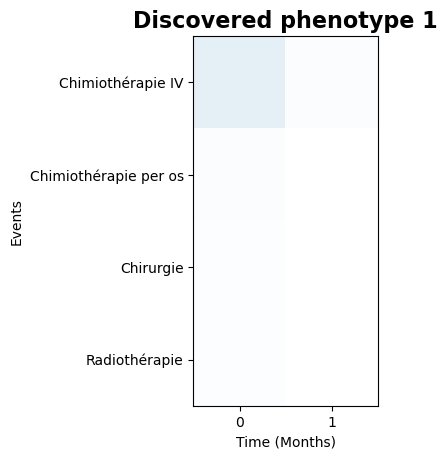

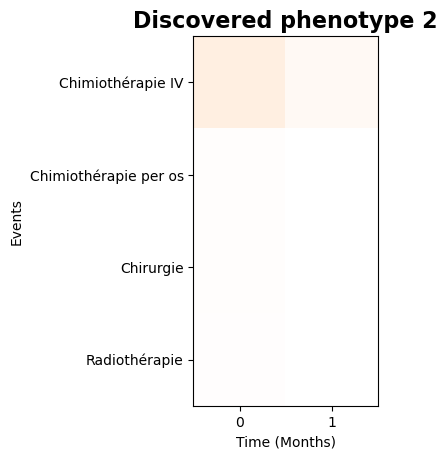

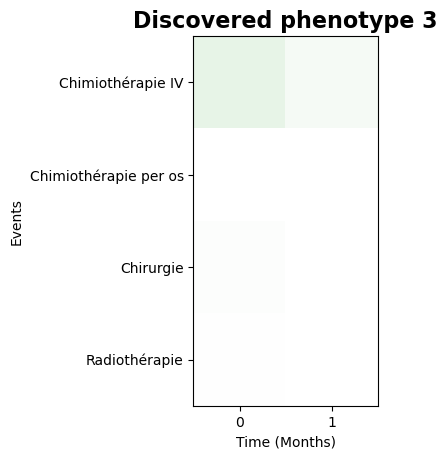

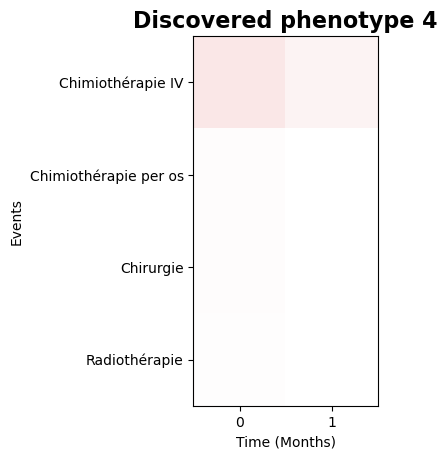

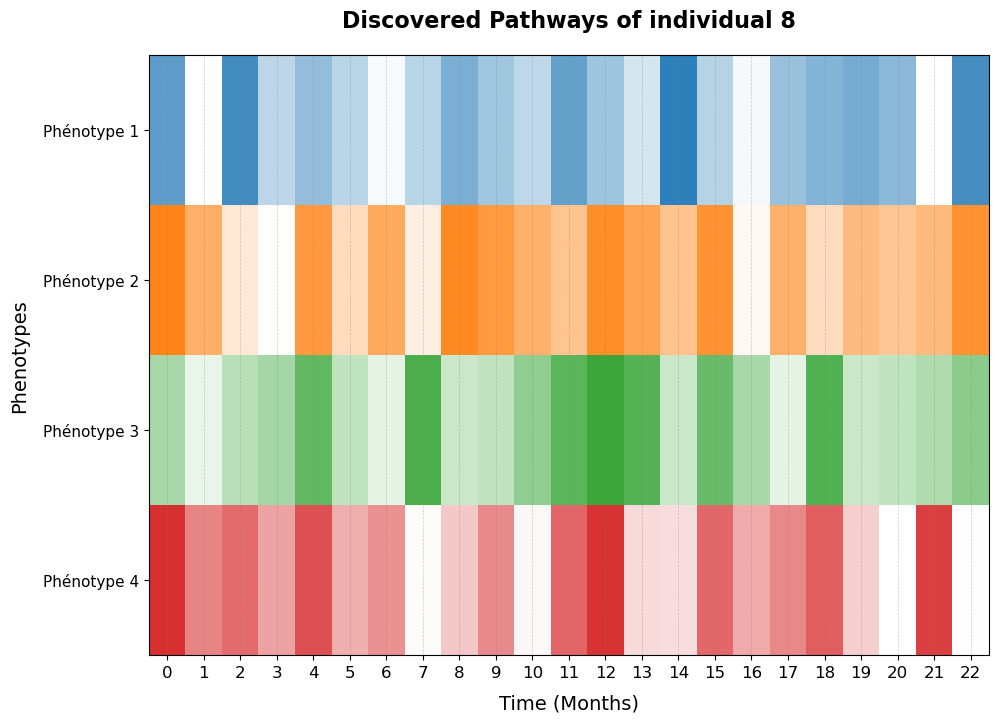

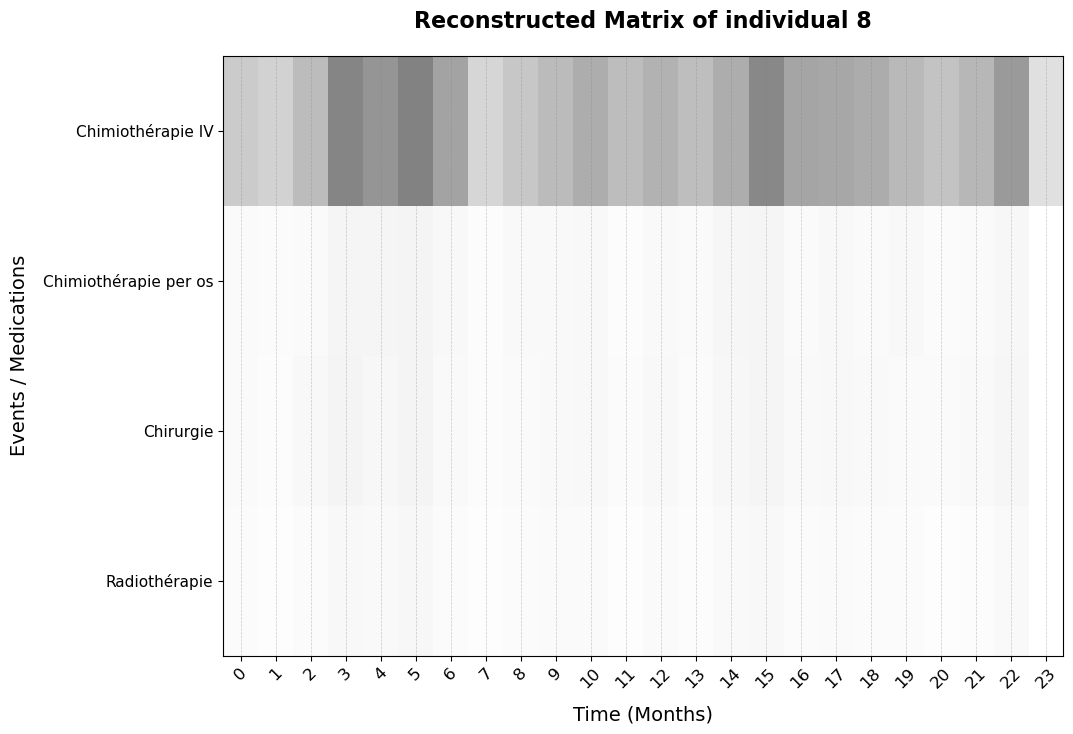

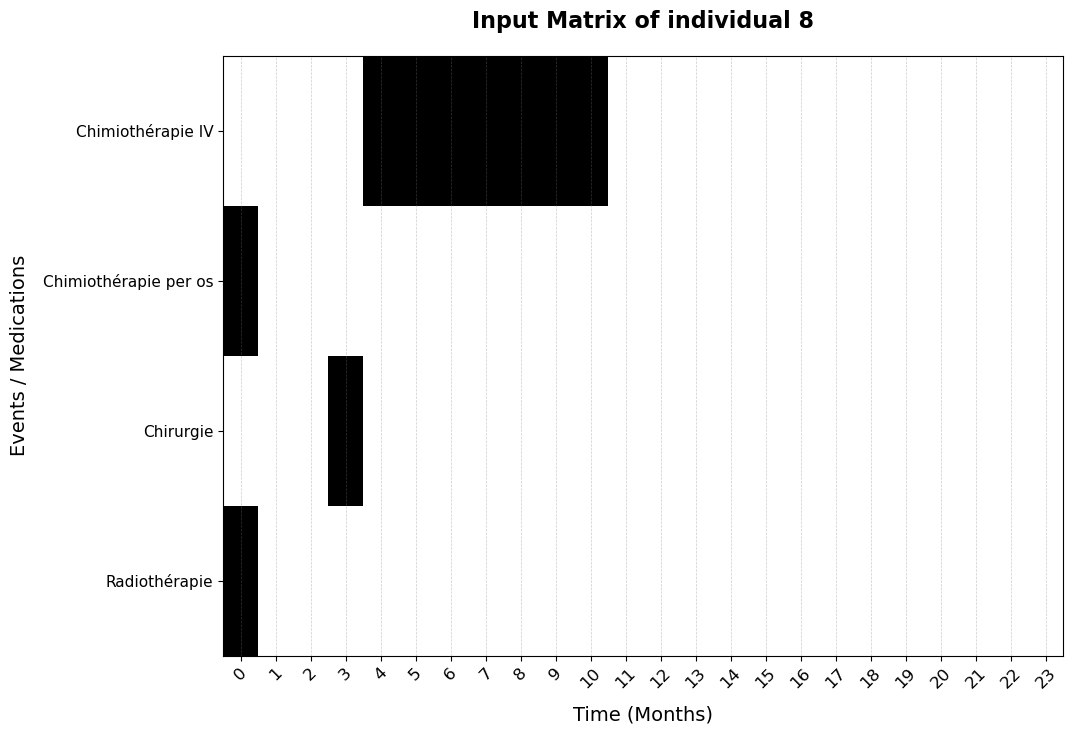

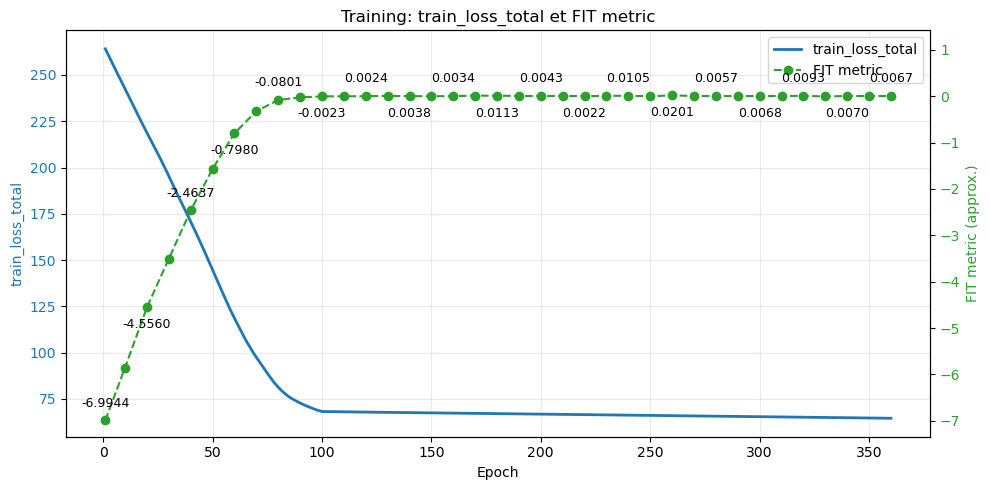

In [26]:
for i, row in results_df4.head(1).iterrows():
    print('\n' + '=' * 90)
    print(f"Configuration #{i+1} : rank={row['rank']}, twl={row['time_window_length']}, "
          f"reg_ns={row['reg_term_ns']}, reg_s={row['reg_term_s']}, learning rate={row['learning_rate']}")
    print(f"  best_fit_metric={row['best_fit_metric']:.4f}, final_fit_metric={row['final_fit_metric']:.4f}")
    
    tca_trial = row['tca_trial']
    labels = timed_event_structure['Event'].unique()
    id_patient = timed_event_structure['ID_PATIENT'].iloc[0]
    
    tca_trial.analyzer.get_decomposition_results(
        labels=tca.label_to_encoded,
        id=8,
        time_unit="Months"
    )

    history = getattr(tca_trial.analyzer, 'training_history', None)
    if not history or len(history.get('epoch', [])) == 0:
        raise ValueError("Aucun historique d'entrainement disponible. Execute d'abord la cellule d'entrainement.")
    
    epochs = history['epoch']
    train_loss_total = history['train_loss_total']
    fit_epochs = history['fit_metric_points_epoch']
    fit_values = history['fit_metric_points_value']

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(epochs, train_loss_total, color='tab:blue', linewidth=2, label='train_loss_total')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('train_loss_total', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(alpha=0.25)

    ax2 = ax1.twinx()
    if len(fit_epochs) > 0:
        ax2.plot(fit_epochs, fit_values, color='tab:green', marker='o', linestyle='--', label='FIT metric')
        for i, (x, y) in enumerate(zip(fit_epochs, fit_values)):
            if i % 2 == 0: 
                y_offset = 10 if i % 4 == 0 else -15 
                ax2.annotate(f"{y:.4f}", (x, y), textcoords='offset points', xytext=(0, y_offset), ha='center', fontsize=9)

        fit_min = min(fit_values)
        fit_max = max(fit_values)
        fit_span = max(fit_max - fit_min, 1e-6)
        ax2.set_ylim(bottom=fit_min - 0.05 * fit_span, top=fit_max + 0.20 * fit_span)

    ax2.set_ylabel('FIT metric (approx.)', color='tab:green')
    ax2.tick_params(axis='y', labelcolor='tab:green')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
    plt.title('Training: train_loss_total et FIT metric')
    plt.tight_layout()
    plt.show()

In [50]:
for i, row in results_df4.iterrows():
    print('\n' + '=' * 90)
    print(f"Configuration #{i+1} : rank={row['rank']}, twl={row['time_window_length']}, "
          f"reg_ns={row['reg_term_ns']}, reg_s={row['reg_term_s']}, learning rate={row['learning_rate']}")
    print(f"  best_fit_metric={row['best_fit_metric']:.4f}, final_fit_metric={row['final_fit_metric']:.4f}")
    
    tca_trial = row['tca_trial']
    labels = timed_event_structure['Event'].unique()
    id_patient = timed_event_structure['ID_PATIENT'].iloc[0]
    
    Ph_tensor = tca_trial.analyzer.model.Ph.detach()

    div_value, pairwise_div = phenotype_diversity(Ph_tensor)

    print(f"Phenotype diversity (average 1 - cosine): {div_value:.6f}\n")

    # Affichage sous forme de DataFrame (tableau)
    col_names = [f"Phenotype_{i+1}" for i in range(pairwise_div.shape[0])]
    pairwise_div_df = pd.DataFrame(
        pairwise_div.cpu().numpy(),
        index=col_names,
        columns=col_names,
    )

    display(pairwise_div_df)


Configuration #1 : rank=4, twl=2, reg_ns=0.99, reg_s=0.99, learning rate=0.0001
  best_fit_metric=0.0201, final_fit_metric=0.0184
Phenotype diversity (average 1 - cosine): 0.018614



,Phenotype_1,Phenotype_2,Phenotype_3,Phenotype_4
Phenotype_1,0.000000,0.019763,0.029654,0.042250
Phenotype_2,0.019763,0.000000,0.004069,0.005636
Phenotype_3,0.029654,0.004069,0.000000,0.010315
Phenotype_4,0.042250,0.005636,0.010315,0.000000


Puis on met un terme de non-succession élevé, avec un petit terme de sparsité.

In [27]:
n_epochs = 500
r = 4
w = 2
s = 1e-5
non_successions = [0.7, 0.8, 0.9, 0.95, 0.99]
lr = 1e-4
results5 = []

for ns in non_successions:
    print('\n' + '=' * 90)
    print(
        f"rank={r}, twl={w}, reg_ns={ns}, reg_s={s}, learning_rate={lr}"
    )

    tca_trial = TCA(
        data=timed_event_structure,
        index_col='ID_PATIENT',
        time_col='Time',
        event_col='Event',
        mode='multidimensional',
    )
    tca_trial.analyzer.transform_time_event_structure_to_tensor()
    tensor_trial = tca_trial.analyzer.get_tensor()
        
    t0 = time.perf_counter()
    tca_trial.analyzer.fit_swotted_decomposition(
        tensor_trial,
        r,
        w,
        ns,
        s,
        metric,
        lr,
        n_epochs,
        fit_metric_every_n_epochs=10,
        fit_metric_eval_max_patients=64,
        num_workers=0,
        early_stopping_patience=10,
        early_stopping_min_delta=1e-4,
        early_stopping_monitor='fit_metric',
    )
        
    elapsed = time.perf_counter() - t0

    hist = getattr(tca_trial.analyzer, 'training_history', {}) or {}
    best_fit = hist.get('best_fit_metric', None)
    best_fit_epoch = hist.get('best_fit_metric_epoch', None)
    final_fit = hist.get('final_fit_metric', None)
    epochs_run = len(hist.get('epoch', []))

    results5.append({
        'rank': r,
        'time_window_length': w,
        'reg_term_ns': ns,
        'reg_term_s': s,
        'learning_rate': lr,
        'epochs_run': epochs_run,
        'best_fit_metric': best_fit,
        'best_fit_epoch': best_fit_epoch,
        'final_fit_metric': final_fit,
        'elapsed_s': round(elapsed, 2),
        'tca_trial': tca_trial
    })

results_df5 = pd.DataFrame(results5)
if not results_df5.empty:
    results_df5 = results_df5.sort_values(
        by=['best_fit_metric', 'final_fit_metric'],
        ascending=False,
        na_position='last'
    ).reset_index(drop=True)

print('\nTop configurations (FIT):')
display(results_df5)

if not results_df5.empty:
    best = results_df5.iloc[0].to_dict()
    print('\nMeilleure configuration candidate:')
    print(best)

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.



rank=4, twl=2, reg_ns=0.7, reg_s=1e-05, learning_rate=0.0001
Dataset :
data shape:  (20435, 3)
state coding:
    label  label encoded
0      0              0
1      1              1
2      2              2
3      3              3


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model        | SlidingWindow | 0      | train | 0    
  | other params | n/a           | 32     | n/a   | n/a  
--------------------------------------


 -> Starting training


c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


...

c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Epoch 1/500 : - train_loss_Ph: 109.831558 - train_loss_W: 148.828461 - train_loss_total: 258.660019 - duration: 3.81s - FIT metric: -8.5067
    early stopping: Metric fit_metric initialized at -8.507.
    checkpoint: New best FIT metric = -8.5067 at epoch 1.
Epoch 2/500 : - train_loss_Ph: 108.941902 - train_loss_W: 147.922440 - train_loss_total: 256.864342 - duration: 4.34s
Epoch 3/500 : - train_loss_Ph: 108.040390 - train_loss_W: 147.004562 - train_loss_total: 255.044952 - duration: 3.63s
Epoch 4/500 : - train_loss_Ph: 107.126633 - train_loss_W: 146.074463 - train_loss_total: 253.201096 - duration: 3.94s
Epoch 5/500 : - train_loss_Ph: 106.200432 - train_loss_W: 145.131882 - train_loss_total: 251.332314 - duration: 4.02s
Epoch 6/500 : - train_loss_Ph: 105.261520 - train_loss_W: 144.176620 - train_loss_total: 249.438141 - duration: 3.92s
Epoch 7/500 : - train_loss_Ph: 104.309715 - train_loss_W: 143.208435 - train_loss_total: 247.518150 - duration: 3.69s
Epoch 8/500 : - train_loss_Ph: 10

,rank,time_window_length,reg_term_ns,reg_term_s,learning_rate,epochs_run,best_fit_metric,best_fit_epoch,final_fit_metric,elapsed_s,tca_trial
0,4,2,0.90,0.00001,0.0001,280,0.018529,180,0.018316,3181.28,<trajectoryclusteringanalysis.tca.TCA object a...
1,4,2,0.70,0.00001,0.0001,360,0.015272,260,0.019464,3707.74,<trajectoryclusteringanalysis.tca.TCA object a...
2,4,2,0.99,0.00001,0.0001,250,0.014112,150,0.020219,2978.58,<trajectoryclusteringanalysis.tca.TCA object a...
3,4,2,0.95,0.00001,0.0001,260,0.010084,160,0.018425,3044.49,<trajectoryclusteringanalysis.tca.TCA object a...
4,4,2,0.80,0.00001,0.0001,220,0.008475,120,0.018903,2749.77,<trajectoryclusteringanalysis.tca.TCA object a...



Meilleure configuration candidate:
{'rank': 4, 'time_window_length': 2, 'reg_term_ns': 0.9, 'reg_term_s': 1e-05, 'learning_rate': 0.0001, 'epochs_run': 280, 'best_fit_metric': 0.018529131128301124, 'best_fit_epoch': 180, 'final_fit_metric': 0.018316096820187755, 'elapsed_s': 3181.28, 'tca_trial': <trajectoryclusteringanalysis.tca.TCA object at 0x000001DE204C6FE0>}



Configuration #1 : rank=4, twl=2, reg_ns=0.9, reg_s=1e-05, learning rate=0.0001
  best_fit_metric=0.0185, final_fit_metric=0.0183
Decomposed into 1336 pathways with rank 4 and time window length 2
Success rate for the entire dataset: 0.0205


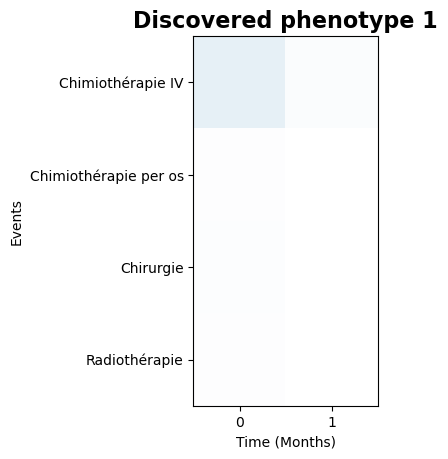

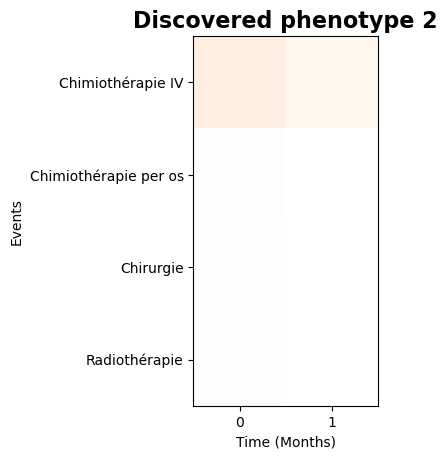

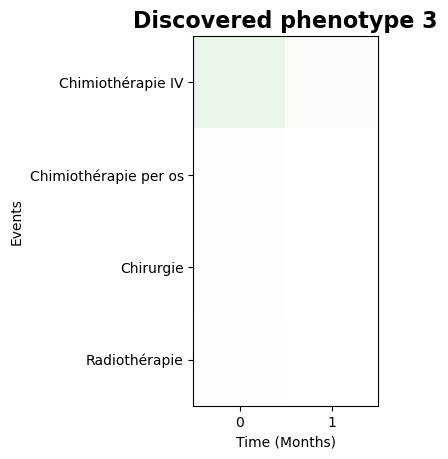

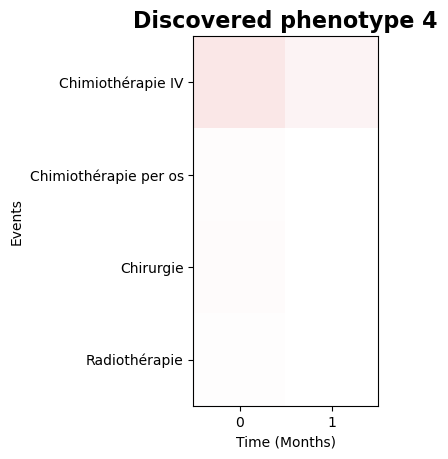

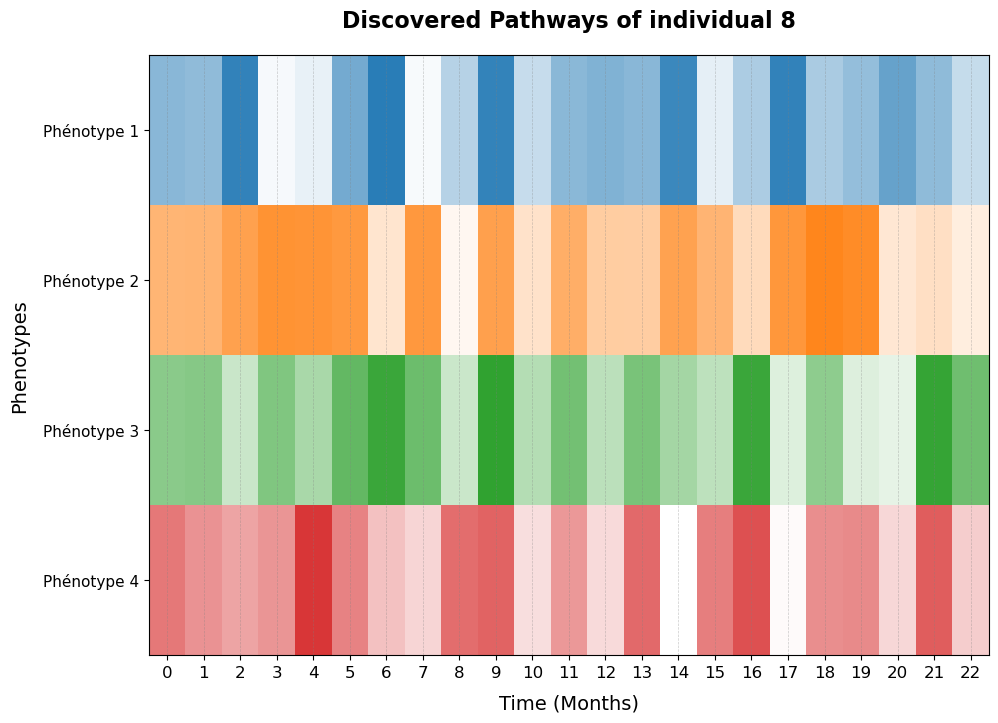

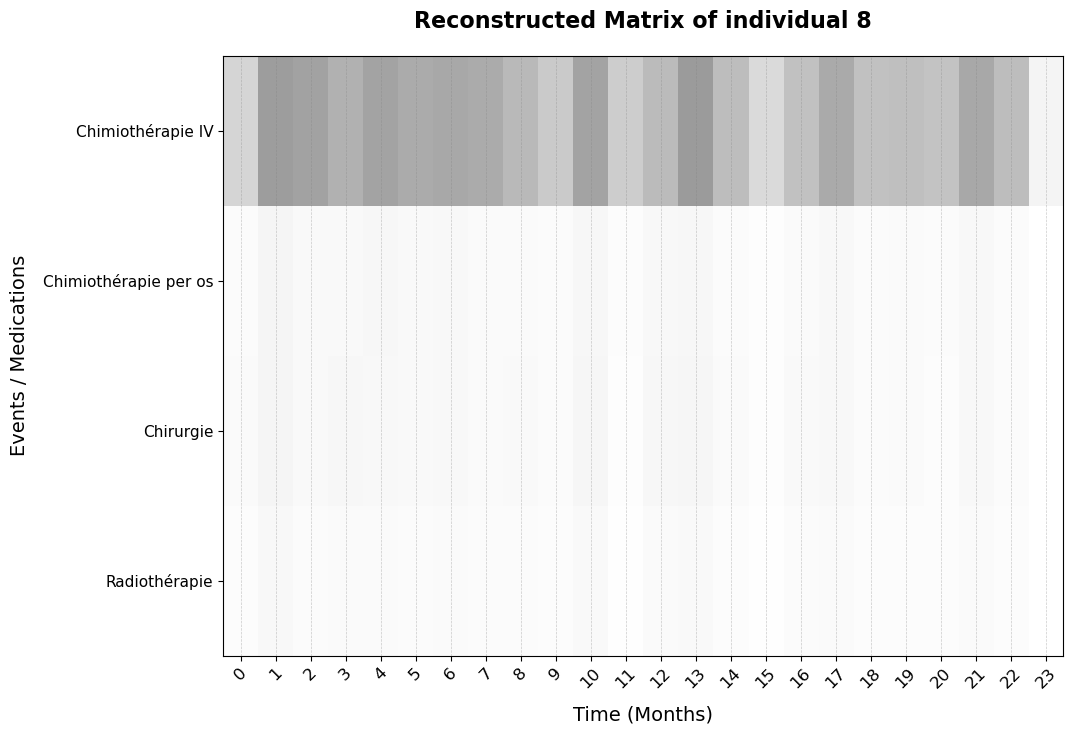

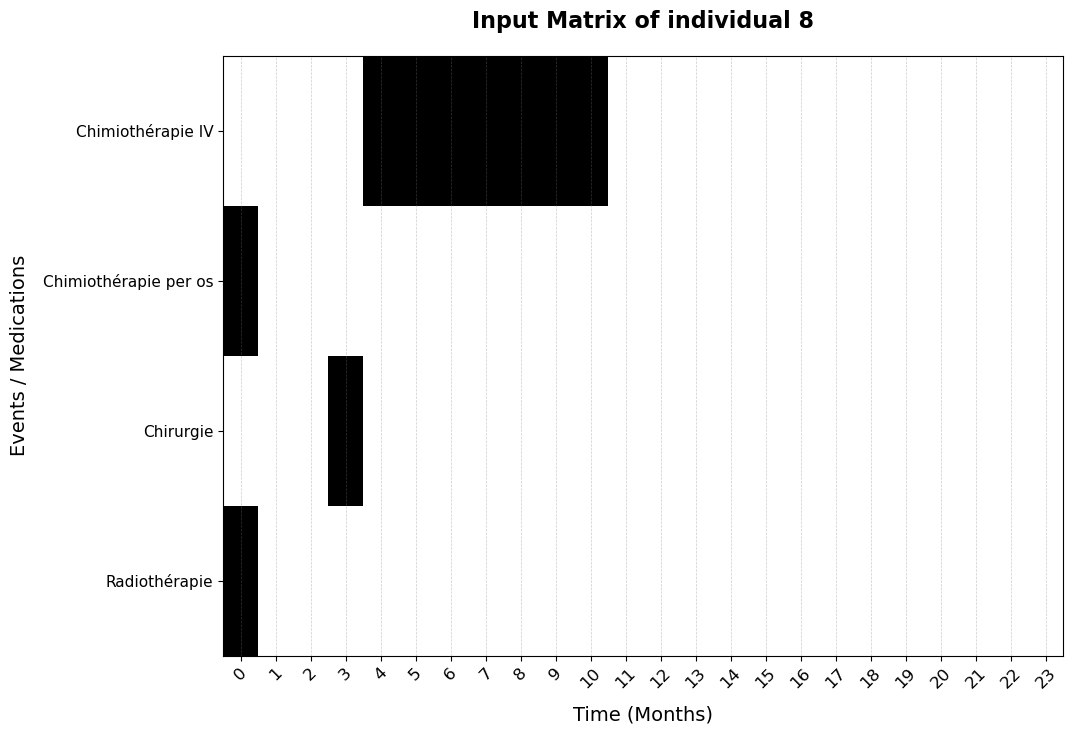

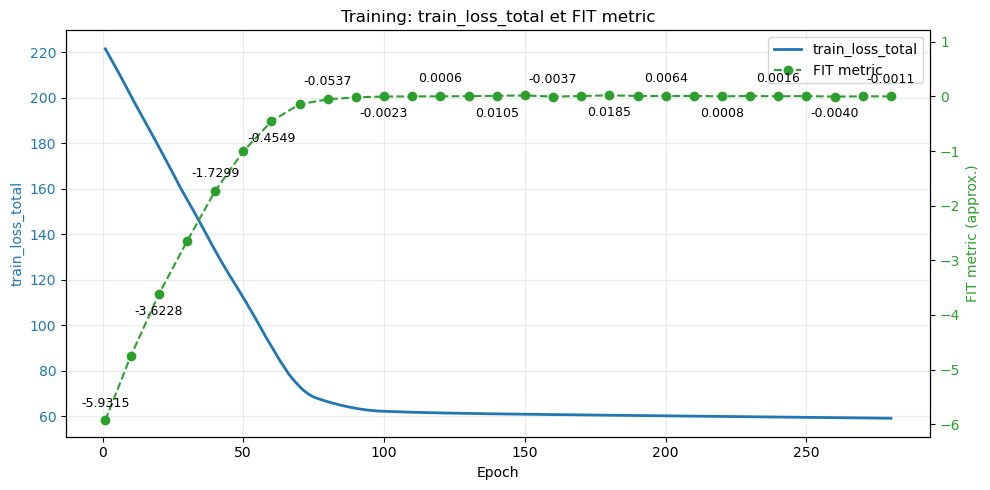

In [28]:
for i, row in results_df5.head(1).iterrows():
    print('\n' + '=' * 90)
    print(f"Configuration #{i+1} : rank={row['rank']}, twl={row['time_window_length']}, "
          f"reg_ns={row['reg_term_ns']}, reg_s={row['reg_term_s']}, learning rate={row['learning_rate']}")
    print(f"  best_fit_metric={row['best_fit_metric']:.4f}, final_fit_metric={row['final_fit_metric']:.4f}")
    
    tca_trial = row['tca_trial']
    labels = timed_event_structure['Event'].unique()
    id_patient = timed_event_structure['ID_PATIENT'].iloc[0]
    
    tca_trial.analyzer.get_decomposition_results(
        labels=tca.label_to_encoded,
        id=8,
        time_unit="Months"
    )

    history = getattr(tca_trial.analyzer, 'training_history', None)
    if not history or len(history.get('epoch', [])) == 0:
        raise ValueError("Aucun historique d'entrainement disponible. Execute d'abord la cellule d'entrainement.")
    
    epochs = history['epoch']
    train_loss_total = history['train_loss_total']
    fit_epochs = history['fit_metric_points_epoch']
    fit_values = history['fit_metric_points_value']

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(epochs, train_loss_total, color='tab:blue', linewidth=2, label='train_loss_total')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('train_loss_total', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(alpha=0.25)

    ax2 = ax1.twinx()
    if len(fit_epochs) > 0:
        ax2.plot(fit_epochs, fit_values, color='tab:green', marker='o', linestyle='--', label='FIT metric')
        for i, (x, y) in enumerate(zip(fit_epochs, fit_values)):
            if i % 2 == 0: 
                y_offset = 10 if i % 4 == 0 else -15 
                ax2.annotate(f"{y:.4f}", (x, y), textcoords='offset points', xytext=(0, y_offset), ha='center', fontsize=9)

        fit_min = min(fit_values)
        fit_max = max(fit_values)
        fit_span = max(fit_max - fit_min, 1e-6)
        ax2.set_ylim(bottom=fit_min - 0.05 * fit_span, top=fit_max + 0.20 * fit_span)

    ax2.set_ylabel('FIT metric (approx.)', color='tab:green')
    ax2.tick_params(axis='y', labelcolor='tab:green')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
    plt.title('Training: train_loss_total et FIT metric')
    plt.tight_layout()
    plt.show()

In [51]:
for i, row in results_df5.iterrows():
    print('\n' + '=' * 90)
    print(f"Configuration #{i+1} : rank={row['rank']}, twl={row['time_window_length']}, "
          f"reg_ns={row['reg_term_ns']}, reg_s={row['reg_term_s']}, learning rate={row['learning_rate']}")
    print(f"  best_fit_metric={row['best_fit_metric']:.4f}, final_fit_metric={row['final_fit_metric']:.4f}")
    
    tca_trial = row['tca_trial']
    labels = timed_event_structure['Event'].unique()
    id_patient = timed_event_structure['ID_PATIENT'].iloc[0]
    
    Ph_tensor = tca_trial.analyzer.model.Ph.detach()

    div_value, pairwise_div = phenotype_diversity(Ph_tensor)

    print(f"Phenotype diversity (average 1 - cosine): {div_value:.6f}\n")

    # Affichage sous forme de DataFrame (tableau)
    col_names = [f"Phenotype_{i+1}" for i in range(pairwise_div.shape[0])]
    pairwise_div_df = pd.DataFrame(
        pairwise_div.cpu().numpy(),
        index=col_names,
        columns=col_names,
    )

    display(pairwise_div_df)


Configuration #1 : rank=4, twl=2, reg_ns=0.9, reg_s=1e-05, learning rate=0.0001
  best_fit_metric=0.0185, final_fit_metric=0.0183
Phenotype diversity (average 1 - cosine): 0.019627



,Phenotype_1,Phenotype_2,Phenotype_3,Phenotype_4
Phenotype_1,0.000000,0.039321,0.005669,0.029972
Phenotype_2,0.039321,0.000000,0.023859,0.006322
Phenotype_3,0.005669,0.023859,0.000000,0.012622
Phenotype_4,0.029972,0.006322,0.012622,0.000000



Configuration #2 : rank=4, twl=2, reg_ns=0.7, reg_s=1e-05, learning rate=0.0001
  best_fit_metric=0.0153, final_fit_metric=0.0195
Phenotype diversity (average 1 - cosine): 0.004251



,Phenotype_1,Phenotype_2,Phenotype_3,Phenotype_4
Phenotype_1,0.000000,0.001671,0.004009,0.010479
Phenotype_2,0.001671,0.000000,0.000890,0.005779
Phenotype_3,0.004009,0.000890,0.000000,0.002677
Phenotype_4,0.010479,0.005779,0.002677,0.000000



Configuration #3 : rank=4, twl=2, reg_ns=0.99, reg_s=1e-05, learning rate=0.0001
  best_fit_metric=0.0141, final_fit_metric=0.0202
Phenotype diversity (average 1 - cosine): 0.020021



,Phenotype_1,Phenotype_2,Phenotype_3,Phenotype_4
Phenotype_1,0.000000,0.021287,0.001916,0.027528
Phenotype_2,0.021287,0.000000,0.030678,0.002006
Phenotype_3,0.001916,0.030678,0.000000,0.036710
Phenotype_4,0.027528,0.002006,0.036710,0.000000



Configuration #4 : rank=4, twl=2, reg_ns=0.95, reg_s=1e-05, learning rate=0.0001
  best_fit_metric=0.0101, final_fit_metric=0.0184
Phenotype diversity (average 1 - cosine): 0.026358



,Phenotype_1,Phenotype_2,Phenotype_3,Phenotype_4
Phenotype_1,0.000000,0.019629,0.052349,0.053731
Phenotype_2,0.019629,0.000000,0.013928,0.008882
Phenotype_3,0.052349,0.013928,0.000000,0.009632
Phenotype_4,0.053731,0.008882,0.009632,0.000000



Configuration #5 : rank=4, twl=2, reg_ns=0.8, reg_s=1e-05, learning rate=0.0001
  best_fit_metric=0.0085, final_fit_metric=0.0189
Phenotype diversity (average 1 - cosine): 0.166109



,Phenotype_1,Phenotype_2,Phenotype_3,Phenotype_4
Phenotype_1,0.000000,0.074813,0.371545,0.323651
Phenotype_2,0.074813,0.000000,0.124289,0.097479
Phenotype_3,0.371545,0.124289,0.000000,0.004878
Phenotype_4,0.323651,0.097479,0.004878,0.000000


Enfin, on fait l'inverse, un petit terme de non-succession pour un grand terme de sparsité.

In [29]:
n_epochs = 500
r = 4
w = 2
sparsities = [0.7, 0.8, 0.9, 0.95, 0.99]
ns = 1e-5
lr = 1e-4
results6 = []

for s in sparsities:
    print('\n' + '=' * 90)
    print(
        f"rank={r}, twl={w}, reg_ns={ns}, reg_s={s}, learning_rate={lr}"
    )

    tca_trial = TCA(
        data=timed_event_structure,
        index_col='ID_PATIENT',
        time_col='Time',
        event_col='Event',
        mode='multidimensional',
    )
    tca_trial.analyzer.transform_time_event_structure_to_tensor()
    tensor_trial = tca_trial.analyzer.get_tensor()
        
    t0 = time.perf_counter()
    tca_trial.analyzer.fit_swotted_decomposition(
        tensor_trial,
        r,
        w,
        ns,
        s,
        metric,
        lr,
        n_epochs,
        fit_metric_every_n_epochs=10,
        fit_metric_eval_max_patients=64,
        num_workers=0,
        early_stopping_patience=10,
        early_stopping_min_delta=1e-4,
        early_stopping_monitor='fit_metric',
    )
        
    elapsed = time.perf_counter() - t0

    hist = getattr(tca_trial.analyzer, 'training_history', {}) or {}
    best_fit = hist.get('best_fit_metric', None)
    best_fit_epoch = hist.get('best_fit_metric_epoch', None)
    final_fit = hist.get('final_fit_metric', None)
    epochs_run = len(hist.get('epoch', []))

    results6.append({
        'rank': r,
        'time_window_length': w,
        'reg_term_ns': ns,
        'reg_term_s': s,
        'learning_rate': lr,
        'epochs_run': epochs_run,
        'best_fit_metric': best_fit,
        'best_fit_epoch': best_fit_epoch,
        'final_fit_metric': final_fit,
        'elapsed_s': round(elapsed, 2),
        'tca_trial': tca_trial
    })

results_df6 = pd.DataFrame(results6)
if not results_df6.empty:
    results_df6 = results_df6.sort_values(
        by=['best_fit_metric', 'final_fit_metric'],
        ascending=False,
        na_position='last'
    ).reset_index(drop=True)

print('\nTop configurations (FIT):')
display(results_df6)

if not results_df6.empty:
    best = results_df6.iloc[0].to_dict()
    print('\nMeilleure configuration candidate:')
    print(best)

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.



rank=4, twl=2, reg_ns=1e-05, reg_s=0.7, learning_rate=0.0001
Dataset :
data shape:  (20435, 3)
state coding:
    label  label encoded
0      0              0
1      1              1
2      2              2
3      3              3


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model        | SlidingWindow | 0      | train | 0    
  | other params | n/a           | 32     | n/a   | n/a  
--------------------------------------


 -> Starting training


c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


...

c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Epoch 1/500 : - train_loss_Ph: 116.493690 - train_loss_W: 99.321442 - train_loss_total: 215.815132 - duration: 3.99s - FIT metric: -7.2678
    early stopping: Metric fit_metric initialized at -7.268.
    checkpoint: New best FIT metric = -7.2678 at epoch 1.
Epoch 2/500 : - train_loss_Ph: 115.215645 - train_loss_W: 98.328209 - train_loss_total: 213.543854 - duration: 3.95s
Epoch 3/500 : - train_loss_Ph: 113.920822 - train_loss_W: 97.319489 - train_loss_total: 211.240311 - duration: 3.98s
Epoch 4/500 : - train_loss_Ph: 112.608765 - train_loss_W: 96.294861 - train_loss_total: 208.903625 - duration: 4.02s
Epoch 5/500 : - train_loss_Ph: 111.279144 - train_loss_W: 95.253975 - train_loss_total: 206.533119 - duration: 4.14s
Epoch 6/500 : - train_loss_Ph: 109.931595 - train_loss_W: 94.196449 - train_loss_total: 204.128044 - duration: 3.35s
Epoch 7/500 : - train_loss_Ph: 108.579674 - train_loss_W: 93.133759 - train_loss_total: 201.713432 - duration: 3.32s
Epoch 8/500 : - train_loss_Ph: 107.24646

,rank,time_window_length,reg_term_ns,reg_term_s,learning_rate,epochs_run,best_fit_metric,best_fit_epoch,final_fit_metric,elapsed_s,tca_trial
0,4,2,0.00001,0.70,0.0001,430,0.050860,330,0.051144,4233.74,<trajectoryclusteringanalysis.tca.TCA object a...
1,4,2,0.00001,0.95,0.0001,340,0.048725,240,0.050932,3618.36,<trajectoryclusteringanalysis.tca.TCA object a...
2,4,2,0.00001,0.90,0.0001,300,0.046502,200,0.052948,3355.76,<trajectoryclusteringanalysis.tca.TCA object a...
3,4,2,0.00001,0.99,0.0001,310,0.045836,210,0.049880,3411.55,<trajectoryclusteringanalysis.tca.TCA object a...
4,4,2,0.00001,0.80,0.0001,460,0.042883,360,0.047768,4466.41,<trajectoryclusteringanalysis.tca.TCA object a...



Meilleure configuration candidate:
{'rank': 4, 'time_window_length': 2, 'reg_term_ns': 1e-05, 'reg_term_s': 0.7, 'learning_rate': 0.0001, 'epochs_run': 430, 'best_fit_metric': 0.05085986103721796, 'best_fit_epoch': 330, 'final_fit_metric': 0.05114360882807456, 'elapsed_s': 4233.74, 'tca_trial': <trajectoryclusteringanalysis.tca.TCA object at 0x000001DE2488EA70>}



Configuration #1 : rank=4, twl=2, reg_ns=1e-05, reg_s=0.7, learning rate=0.0001
  best_fit_metric=0.0509, final_fit_metric=0.0511
Decomposed into 1336 pathways with rank 4 and time window length 2
Success rate for the entire dataset: 0.0511


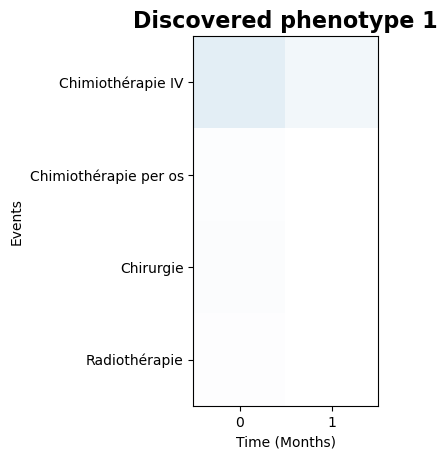

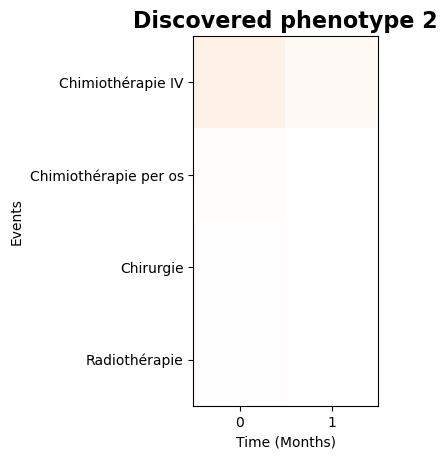

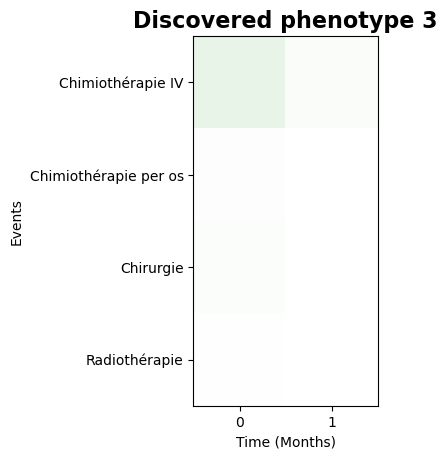

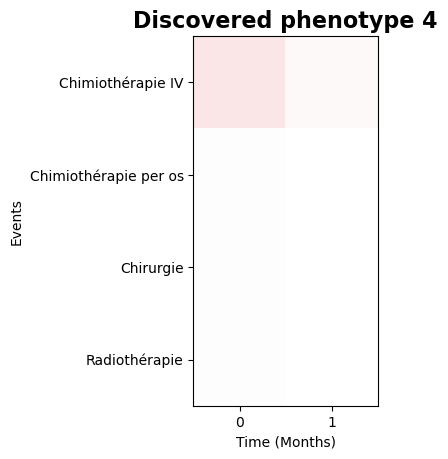

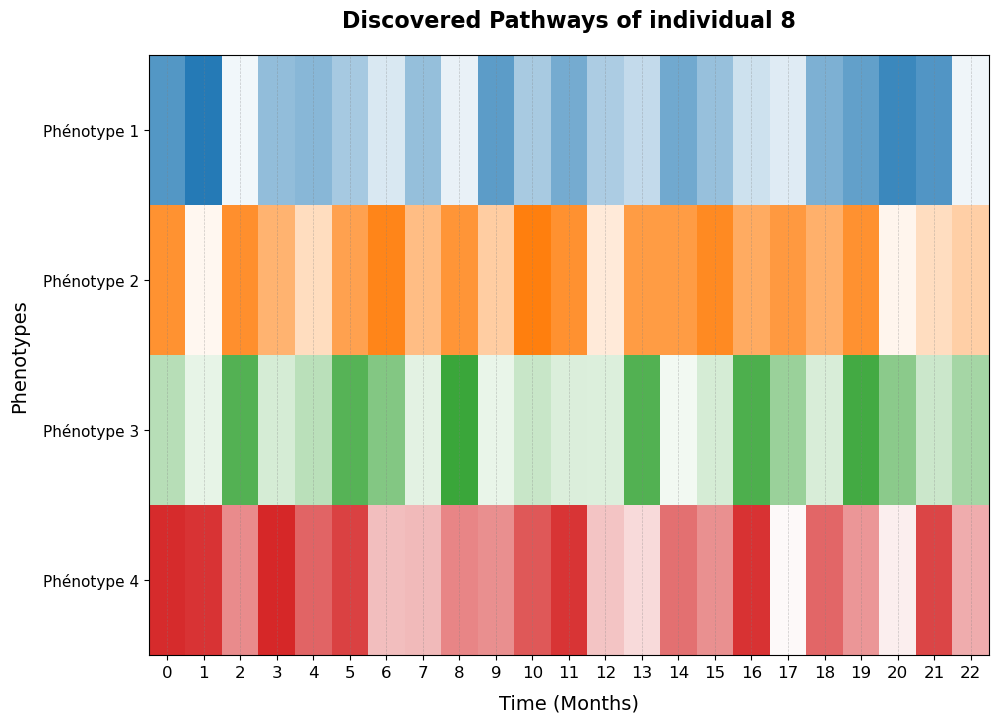

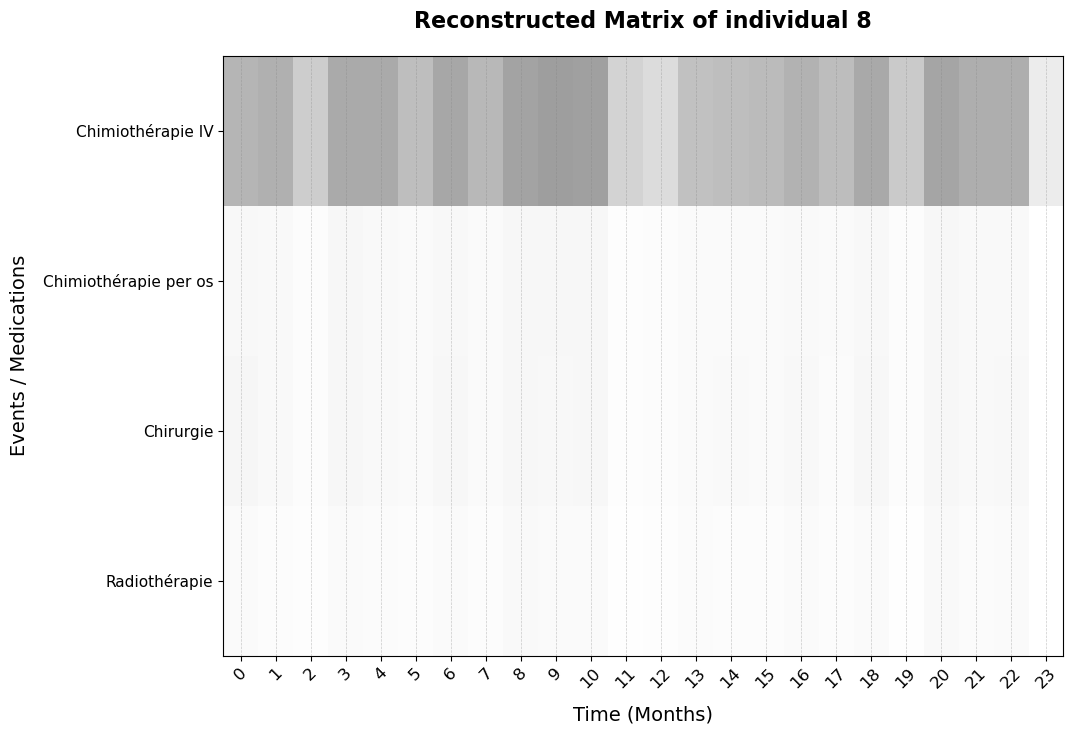

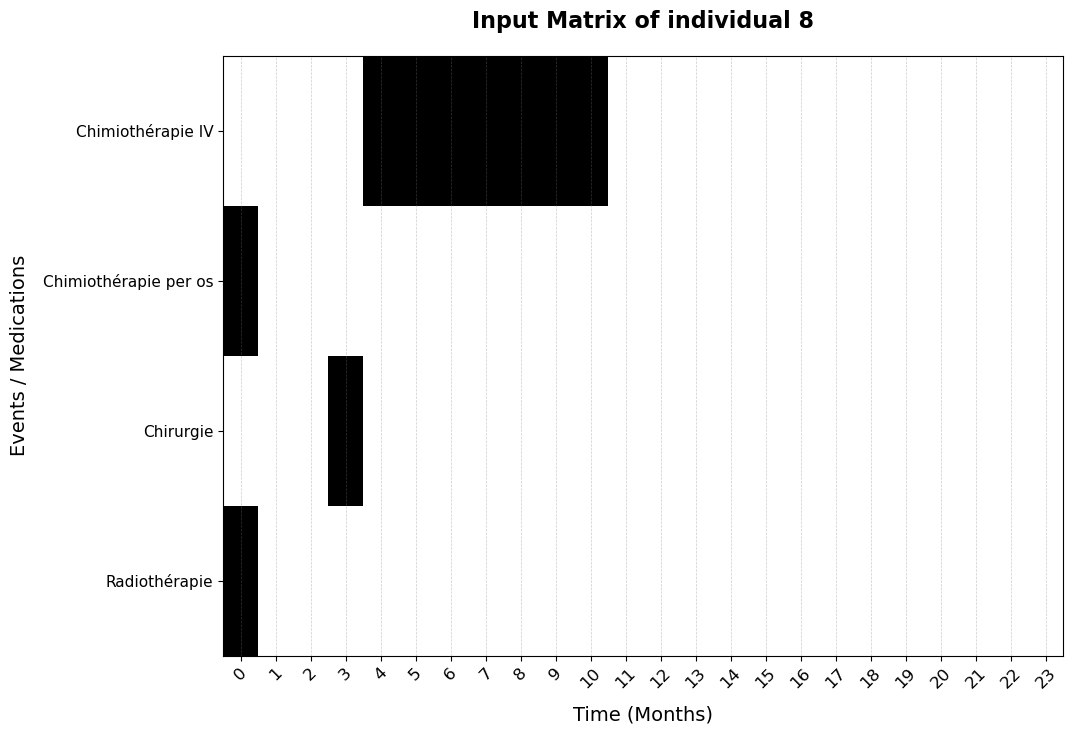

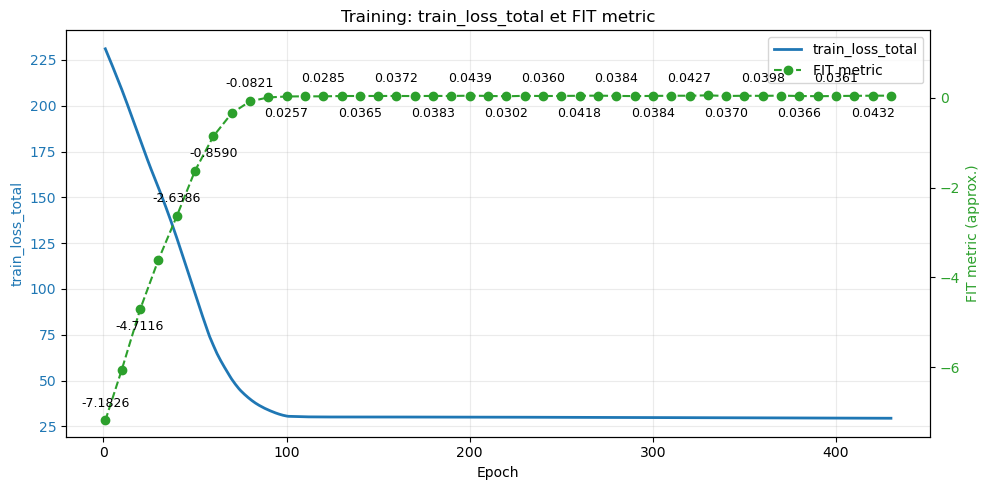

In [30]:
for i, row in results_df6.head(1).iterrows():
    print('\n' + '=' * 90)
    print(f"Configuration #{i+1} : rank={row['rank']}, twl={row['time_window_length']}, "
          f"reg_ns={row['reg_term_ns']}, reg_s={row['reg_term_s']}, learning rate={row['learning_rate']}")
    print(f"  best_fit_metric={row['best_fit_metric']:.4f}, final_fit_metric={row['final_fit_metric']:.4f}")
    
    tca_trial = row['tca_trial']
    labels = timed_event_structure['Event'].unique()
    id_patient = timed_event_structure['ID_PATIENT'].iloc[0]
    
    tca_trial.analyzer.get_decomposition_results(
        labels=tca.label_to_encoded,
        id=8,
        time_unit="Months"
    )

    history = getattr(tca_trial.analyzer, 'training_history', None)
    if not history or len(history.get('epoch', [])) == 0:
        raise ValueError("Aucun historique d'entrainement disponible. Execute d'abord la cellule d'entrainement.")
    
    epochs = history['epoch']
    train_loss_total = history['train_loss_total']
    fit_epochs = history['fit_metric_points_epoch']
    fit_values = history['fit_metric_points_value']

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(epochs, train_loss_total, color='tab:blue', linewidth=2, label='train_loss_total')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('train_loss_total', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(alpha=0.25)

    ax2 = ax1.twinx()
    if len(fit_epochs) > 0:
        ax2.plot(fit_epochs, fit_values, color='tab:green', marker='o', linestyle='--', label='FIT metric')
        for i, (x, y) in enumerate(zip(fit_epochs, fit_values)):
            if i % 2 == 0: 
                y_offset = 10 if i % 4 == 0 else -15 
                ax2.annotate(f"{y:.4f}", (x, y), textcoords='offset points', xytext=(0, y_offset), ha='center', fontsize=9)

        fit_min = min(fit_values)
        fit_max = max(fit_values)
        fit_span = max(fit_max - fit_min, 1e-6)
        ax2.set_ylim(bottom=fit_min - 0.05 * fit_span, top=fit_max + 0.20 * fit_span)

    ax2.set_ylabel('FIT metric (approx.)', color='tab:green')
    ax2.tick_params(axis='y', labelcolor='tab:green')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
    plt.title('Training: train_loss_total et FIT metric')
    plt.tight_layout()
    plt.show()

In [53]:
for i, row in results_df6.iterrows():
    print('\n' + '=' * 90)
    print(f"Configuration #{i+1} : rank={row['rank']}, twl={row['time_window_length']}, "
          f"reg_ns={row['reg_term_ns']}, reg_s={row['reg_term_s']}, learning rate={row['learning_rate']}")
    print(f"  best_fit_metric={row['best_fit_metric']:.4f}, final_fit_metric={row['final_fit_metric']:.4f}")
    
    tca_trial = row['tca_trial']
    labels = timed_event_structure['Event'].unique()
    id_patient = timed_event_structure['ID_PATIENT'].iloc[0]
    
    Ph_tensor = tca_trial.analyzer.model.Ph.detach()

    div_value, pairwise_div = phenotype_diversity(Ph_tensor)

    print(f"Phenotype diversity (average 1 - cosine): {div_value:.6f}\n")

    # Affichage sous forme de DataFrame (tableau)
    col_names = [f"Phenotype_{i+1}" for i in range(pairwise_div.shape[0])]
    pairwise_div_df = pd.DataFrame(
        pairwise_div.cpu().numpy(),
        index=col_names,
        columns=col_names,
    )

    display(pairwise_div_df)


Configuration #1 : rank=4, twl=2, reg_ns=1e-05, reg_s=0.7, learning rate=0.0001
  best_fit_metric=0.0509, final_fit_metric=0.0511
Phenotype diversity (average 1 - cosine): 0.008066



,Phenotype_1,Phenotype_2,Phenotype_3,Phenotype_4
Phenotype_1,0.000000,0.005351,0.012562,0.017693
Phenotype_2,0.005351,0.000000,0.004435,0.005553
Phenotype_3,0.012562,0.004435,0.000000,0.002802
Phenotype_4,0.017693,0.005553,0.002802,0.000000



Configuration #2 : rank=4, twl=2, reg_ns=1e-05, reg_s=0.95, learning rate=0.0001
  best_fit_metric=0.0487, final_fit_metric=0.0509
Phenotype diversity (average 1 - cosine): 0.009971



,Phenotype_1,Phenotype_2,Phenotype_3,Phenotype_4
Phenotype_1,0.000000,0.017321,0.011423,0.017932
Phenotype_2,0.017321,0.000000,0.004880,0.002025
Phenotype_3,0.011423,0.004880,0.000000,0.006245
Phenotype_4,0.017932,0.002025,0.006245,0.000000



Configuration #3 : rank=4, twl=2, reg_ns=1e-05, reg_s=0.9, learning rate=0.0001
  best_fit_metric=0.0465, final_fit_metric=0.0529
Phenotype diversity (average 1 - cosine): 0.004783



,Phenotype_1,Phenotype_2,Phenotype_3,Phenotype_4
Phenotype_1,0.000000,0.003320,0.000629,0.009155
Phenotype_2,0.003320,0.000000,0.004402,0.002278
Phenotype_3,0.000629,0.004402,0.000000,0.008917
Phenotype_4,0.009155,0.002278,0.008917,0.000000



Configuration #4 : rank=4, twl=2, reg_ns=1e-05, reg_s=0.99, learning rate=0.0001
  best_fit_metric=0.0458, final_fit_metric=0.0499
Phenotype diversity (average 1 - cosine): 0.023355



,Phenotype_1,Phenotype_2,Phenotype_3,Phenotype_4
Phenotype_1,0.000000,0.020319,0.058386,0.035229
Phenotype_2,0.020319,0.000000,0.012964,0.004816
Phenotype_3,0.058386,0.012964,0.000000,0.008413
Phenotype_4,0.035229,0.004816,0.008413,0.000000



Configuration #5 : rank=4, twl=2, reg_ns=1e-05, reg_s=0.8, learning rate=0.0001
  best_fit_metric=0.0429, final_fit_metric=0.0478
Phenotype diversity (average 1 - cosine): 0.065529



,Phenotype_1,Phenotype_2,Phenotype_3,Phenotype_4
Phenotype_1,0.000000,0.140669,0.021733,0.003203
Phenotype_2,0.140669,0.000000,0.083841,0.129686
Phenotype_3,0.021733,0.083841,0.000000,0.014044
Phenotype_4,0.003203,0.129686,0.014044,0.000000
